# Notebook 18 — Empirical eventless counterfactual and weights

This notebook uses the frozen empirical states $Q_t$, $R_t$, and $I_t=\mathrm{iv\_model\_var}$, indexed by the canonical model day $[D-1,17{:}00\ \mathrm{New\ York},D,17{:}00\ \mathrm{New\ York})$.

Scheduled events are mapped to the model day containing their timestamp. Realised and implied variance use that same event-containing model day. The exact Bloomberg daily ATM implied-volatility snapshot/fixing time is not identified by the available metadata, so this is an empirical modelling/alignment convention rather than a claim about Bloomberg's proprietary fixing mechanism.


## 1. Frozen upstream contract and reproducibility guardrails

Notebook 17 is frozen: $n=1$, $m=12$, retained predictor blocks, OLS, chronological splits, and the lag-before-mask discipline are unchanged. VALIDATION and TEST do not select event timing, specification, or frozen positive-domain floors.


In [29]:
from pathlib import Path
import math
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

RUN_ID = pd.Timestamp.now(tz="UTC").isoformat()
PROJECT_MARKER = "00_model_specification_and_core_simulator.ipynb"

def find_project_root(start=None):
    """Find the project from the current directory or one of its parents."""
    start = (Path.cwd() if start is None else Path(start)).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "Data").is_dir() and (candidate / PROJECT_MARKER).is_file():
            return candidate
    raise RuntimeError(
        "Could not locate the FX volatility project root. "
        "Start the notebook from the project directory or one of its subdirectories; "
        f"expected both Data/ and {PROJECT_MARKER}."
    )

PROJECT_ROOT = find_project_root()
PROCESSED = PROJECT_ROOT / "Data" / "processed"
INTERIM = PROJECT_ROOT / "Data" / "interim"
FIGURES = PROJECT_ROOT / "figures"

def sha256_file(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

NOTEBOOK_DIR = PROJECT_ROOT
PROTECTED_NOTEBOOK_PATHS = [
    NOTEBOOK_DIR / name for name in [
        "14_empirical_data_audit_and_alignment.ipynb",
        "15_empirical_variable_construction.ipynb",
        "16_empirical_gc_tdmi_dependence_structure.ipynb",
        "17_empirical_parametric_calibration_and_forecasting.ipynb",
        "19_empirical_nonparametric_causal_structure_and_event_weights.ipynb",
        "20_empirical_event_weight_api.ipynb",
        "21_empirical_hidden_event_discovery_and_signal_synthesis.ipynb",
    ]
]
assert all(path.exists() for path in PROTECTED_NOTEBOOK_PATHS)
protected_hashes_before = {path.name: sha256_file(path) for path in PROTECTED_NOTEBOOK_PATHS}

# Frozen in Notebook 17 from TRAIN strictly-positive target observations.
FORECAST_FLOORS = {"R": 0.0003202993332501, "I": 0.0015767239436135}

def parse_bool(value):
    text = str(value).strip().lower()
    if text in {"true", "1"}:
        return True
    if text in {"false", "0"}:
        return False
    raise ValueError(f"Cannot parse boolean: {value!r}")

def bool_series(series):
    mapped = series.astype(str).str.strip().str.lower().map(
        {"true": True, "false": False, "1": True, "0": False}
    )
    assert mapped.notna().all()
    return mapped.astype(bool)

spec16 = pd.read_csv(PROCESSED / "16_primary_specification.csv").dropna(subset=["iv_specification"]).iloc[0]
spec17 = pd.read_csv(PROCESSED / "17_primary_specification.csv").iloc[0]
expected_contract = {
    "iv_specification": "WEEKDAY_NORM_IV",
    "iv_column": "iv_model_var",
    "selected_n": 1,
    "selected_m": 12,
    "retain_Q_to_R": False,
    "retain_I_to_R": True,
    "retain_Q_to_I": True,
    "retain_R_to_I": True,
    "event_unaware": True,
    "eventless": False,
    "equation_5_implemented": False,
}
for key, expected in expected_contract.items():
    observed = (
        parse_bool(spec16[key]) if isinstance(expected, bool)
        else int(spec16[key]) if isinstance(expected, int)
        else str(spec16[key])
    )
    assert observed == expected, f"Frozen Notebook 16 contract mismatch: {key}={observed!r}"
assert parse_bool(spec17["exercise_2_complete"])
assert spec17["primary_realised_model"] == "R_PRIMARY_AR1_IV"
assert spec17["primary_implied_model"] == "I_PRIMARY_FULL_12"
IV_COLUMN = str(spec16["iv_column"])

print(f"Frozen contract loaded: {IV_COLUMN}; n={int(spec16.selected_n)}, m={int(spec16.selected_m)}")

Frozen contract loaded: iv_model_var; n=1, m=12


## 2. Intact states and chronological lags

All 36 lags are constructed on the complete canonical chronology before any event mask. Event-day observations remain intact and can enter later forecasts as observed lagged states.

In [30]:
panel = (
    pd.read_csv(PROCESSED / "16_empirical_analysis_panel.csv", parse_dates=["model_day"])
    .sort_values("model_day")
    .reset_index(drop=True)
)
rv_source = (
    pd.read_csv(
        PROCESSED / "usdjpy_daily_model_panel.csv",
        usecols=[
            "model_day", "valid_hourly_return_count", "rv_complete_24h",
            "rv_full_session_stale", "rv_eligible",
        ],
        parse_dates=["model_day"],
    )
    .sort_values("model_day")
    .reset_index(drop=True)
)
for column in ["rv_complete_24h", "rv_full_session_stale", "rv_eligible"]:
    rv_source[column] = bool_series(rv_source[column])

required = {
    "model_day", "sample_split", "squared_return",
    "realised_variance_ann_252", IV_COLUMN,
}
assert required.issubset(panel.columns)
assert panel["model_day"].is_unique and panel["model_day"].is_monotonic_increasing
assert panel["model_day"].equals(rv_source["model_day"])

panel["Q"] = pd.to_numeric(panel["squared_return"], errors="coerce")
panel["R"] = pd.to_numeric(panel["realised_variance_ann_252"], errors="coerce")
panel["I"] = pd.to_numeric(panel[IV_COLUMN], errors="coerce")
state_snapshot = panel[["model_day", "Q", "R", "I"]].copy()

for state in ["Q", "R", "I"]:
    for lag in range(1, 13):
        panel[f"{state}_lag{lag}"] = panel[state].shift(lag)
lag_columns = [
    f"{state}_lag{lag}" for state in ["Q", "R", "I"] for lag in range(1, 13)
]
lag_snapshot = panel[["model_day", *lag_columns]].copy()
R_FEATURES = ["R_lag1", "I_lag1"]
I_FEATURES = [
    f"{state}_lag{lag}" for state in ["Q", "R", "I"] for lag in range(1, 13)
]
BASE_COLUMNS = {
    "R": ["R", "Q_lag1", "R_lag1", "I_lag1"],
    "I": ["I", *I_FEATURES],
}
for target in ["R", "I"]:
    panel[f"{target}_base_eligible"] = np.isfinite(panel[BASE_COLUMNS[target]]).all(axis=1)

base_counts = panel.groupby("sample_split")[
    ["R_base_eligible", "I_base_eligible"]
].sum().astype(int)
assert tuple(base_counts.loc["train"]) == (3005, 2226)
assert tuple(base_counts.loc["validation"]) == (1181, 1087)
split_dates = panel.groupby("sample_split")["model_day"].agg(["min", "max", "count"])
assert split_dates.loc["train", "min"] == pd.Timestamp("2003-05-05")
assert split_dates.loc["train", "max"] == pd.Timestamp("2017-03-27")
assert split_dates.loc["validation", "min"] == pd.Timestamp("2017-03-28")
assert split_dates.loc["test", "min"] == pd.Timestamp("2021-11-15")
display(base_counts)
display(split_dates)

,R_base_eligible,I_base_eligible
sample_split,,
test,1182,1071
train,3005,2226
validation,1181,1087


,min,max,count
sample_split,,,
test,2021-11-15,2026-07-02,1209
train,2003-05-05,2017-03-27,3626
validation,2017-03-28,2021-11-12,1209


## 3. Six-family occurrences and target-specific timing contract

Raw Bloomberg component rows are mapped to the observed 17:00 New York session containing the timestamp. Realised events remain on the event-containing model day $D$. The implied-volatility event observation is the last defensible daily IV observation preceding the announcement under the separate TRAIN-only timing audit in `18A_implied_event_timing_audit.ipynb`: FOMC uses $I_D$; US Employment, US CPI, BoJ, JPY National CPI and JPY GDP use $I_{D-1}$, where $D-1$ is the immediately previous observed canonical model-day row (not calendar subtraction). Calendar labels therefore differ by family while the economic information point is held consistent. The precise proprietary Bloomberg snapshot time is not claimed to be known; this is an empirically supported operational convention.

The implied side is aligned to a common pre-announcement information point, whereas the event-containing realised model day contains unequal amounts of post-announcement variation across families. Thus cross-family realised weights combine event intensity with unequal post-event exposure; no correction is applied.


In [31]:
FAMILY_LABELS = {
    "FOMC": ["FOMC Rate Decision (Upper Bound)"],
    "US Employment": ["Change in Nonfarm Payrolls", "Unemployment Rate"],
    "US CPI": ["CPI MoM", "CPI YoY"],
    "BoJ": ["BOJ Target Rate"],
    "JPY National CPI": ["Natl CPI YoY"],
    "JPY GDP": ["GDP SA QoQ", "GDP Annualized SA QoQ", "GDP Deflator YoY"],
}
label_to_family = {
    label: family for family, labels in FAMILY_LABELS.items() for label in labels
}
event_family_mapping = pd.DataFrame(
    [(label, family) for label, family in label_to_family.items()],
    columns=["raw_event_label", "mapped_family"],
)

raw_events = pd.read_csv(INTERIM / "g10_usd_jpy_events_audited.csv")
raw_events = (
    raw_events.loc[raw_events["event"].isin(label_to_family)]
    .copy()
    .reset_index(names="raw_event_id")
)
raw_events["raw_event_label"] = raw_events["event"]
raw_events["mapped_family"] = raw_events["event"].map(label_to_family)
raw_events["event_timestamp_original"] = raw_events["event_datetime_utc"].astype(str)
raw_events["event_datetime_utc"] = pd.to_datetime(
    raw_events["event_datetime_utc"], utc=True, errors="coerce", format="mixed"
)
raw_events["event_datetime_ny"] = raw_events["event_datetime_utc"].dt.tz_convert(
    "America/New_York"
)

sessions = pd.DataFrame({"model_day": panel["model_day"]})
sessions["session_open_naive"] = (
    sessions["model_day"] - pd.Timedelta(days=1) + pd.Timedelta(hours=17)
)
sessions["session_close_naive"] = sessions["model_day"] + pd.Timedelta(hours=17)
sessions["session_open_ny"] = sessions["session_open_naive"].dt.tz_localize(
    "America/New_York"
)
sessions["session_close_ny"] = sessions["session_close_naive"].dt.tz_localize(
    "America/New_York"
)
sessions["session_open_utc"] = sessions["session_open_ny"].dt.tz_convert("UTC")
sessions["session_close_utc"] = sessions["session_close_ny"].dt.tz_convert("UTC")
assert sessions["session_open_ny"].dt.hour.eq(17).all()
assert sessions["session_close_ny"].dt.hour.eq(17).all()

valid_events = (
    raw_events.loc[raw_events["event_datetime_utc"].notna()]
    .sort_values("event_datetime_utc")
    .copy()
)
probed = pd.merge_asof(
    valid_events,
    sessions[[
        "model_day", "session_open_utc", "session_close_utc",
    ]].sort_values("session_open_utc"),
    left_on="event_datetime_utc",
    right_on="session_open_utc",
    direction="backward",
)
probed["explicit_member"] = (
    probed["session_open_utc"].le(probed["event_datetime_utc"])
    & probed["event_datetime_utc"].lt(probed["session_close_utc"])
)
probed["mapped_model_day"] = probed["model_day"].where(probed["explicit_member"])
panel_start = sessions["session_open_utc"].min()
panel_end = sessions["session_close_utc"].max()
probed["mapping_status"] = np.select(
    [
        probed["explicit_member"],
        ~probed["event_datetime_utc"].between(
            panel_start, panel_end, inclusive="both"
        ),
    ],
    ["MAPPED", "OUTSIDE_EMPIRICAL_PANEL"],
    default="NO_EXISTING_SESSION_INTERVAL",
)
mapping_audit = raw_events[[
    "raw_event_id", "raw_event_label", "mapped_family",
    "event_timestamp_original", "event_datetime_utc", "event_datetime_ny",
]].merge(
    probed[[
        "raw_event_id", "mapped_model_day", "mapping_status", "explicit_member",
    ]],
    on="raw_event_id",
    how="left",
)
mapping_audit["mapping_status"] = mapping_audit["mapping_status"].fillna(
    "INVALID_TIMESTAMP"
)
mapping_audit["explicit_member"] = mapping_audit["explicit_member"].eq(True)
mapping_audit["mapped_model_day"] = pd.to_datetime(
    mapping_audit["mapped_model_day"]
)
display(mapping_audit["mapping_status"].value_counts().to_frame("raw_rows"))

,raw_rows
mapping_status,
MAPPED,2315
OUTSIDE_EMPIRICAL_PANEL,310
NO_EXISTING_SESSION_INTERVAL,1


In [32]:
modelled_raw = mapping_audit.loc[mapping_audit["mapping_status"].eq("MAPPED")].copy()
assert bool(modelled_raw["explicit_member"].all() and modelled_raw["event_datetime_utc"].notna().all())
occurrences = (modelled_raw.groupby(["mapped_family","mapped_model_day"],as_index=False).agg(raw_row_count=("raw_event_id","size"),raw_labels=("raw_event_label",lambda x:" | ".join(sorted(set(x))),),n_unique_raw_timestamps=("event_datetime_utc","nunique"),first_event_time_utc=("event_datetime_utc","min"),last_event_time_utc=("event_datetime_utc","max")).rename(columns={"mapped_family":"family","mapped_model_day":"realised_model_day"}))
first_original=(modelled_raw.sort_values("event_datetime_utc").drop_duplicates(["mapped_family","mapped_model_day"])[["mapped_family","mapped_model_day","event_timestamp_original"]].rename(columns={"mapped_family":"family","mapped_model_day":"realised_model_day"}))
occurrences=occurrences.merge(first_original,on=["family","realised_model_day"],how="left",validate="one_to_one")
occurrences["release_span_seconds"]=(occurrences.last_event_time_utc-occurrences.first_event_time_utc).dt.total_seconds()
occurrences["event_id"]=occurrences.family.str.replace(r"[^A-Za-z0-9]+","_",regex=True).str.strip("_")+"__"+occurrences.realised_model_day.dt.strftime("%Y%m%d")
occurrences["event_label"]=occurrences.family
occurrences["event_timestamp_utc"]=occurrences.first_event_time_utc
occurrences["event_timestamp_ny"]=occurrences.event_timestamp_utc.dt.tz_convert("America/New_York")
split_lookup=panel.set_index("model_day").sample_split
canonical_day_index = pd.Series(np.arange(len(panel)), index=panel["model_day"].to_numpy())
canonical_day_lookup = pd.Series(panel["model_day"].to_numpy(), index=np.arange(len(panel)))
TIMING_CONTRACT = {
    "FOMC": (0, "DIRECT_EVIDENCE"),
    "US Employment": (-1, "DIRECT_EVIDENCE"),
    "US CPI": (-1, "DEDUCED_FROM_TIMING_BRACKET"),
    "BoJ": (-1, "DIRECT_EVIDENCE"),
    "JPY National CPI": (-1, "DEDUCED_FROM_TIMING_BRACKET"),
    "JPY GDP": (-1, "DEDUCED_FROM_TIMING_BRACKET"),
}
assert set(TIMING_CONTRACT) == set(FAMILY_LABELS)
occurrences["realised_event_offset"] = 0
occurrences["implied_event_offset"] = occurrences["family"].map(lambda family: TIMING_CONTRACT[family][0]).astype(int)
occurrences["timing_evidence_basis"] = occurrences["family"].map(lambda family: TIMING_CONTRACT[family][1])
occurrences["realised_canonical_row"] = occurrences["realised_model_day"].map(canonical_day_index)
assert occurrences["realised_canonical_row"].notna().all()
occurrences["implied_canonical_row"] = occurrences["realised_canonical_row"].astype(int) + occurrences["implied_event_offset"]
occurrences["implied_model_day"] = occurrences["implied_canonical_row"].map(canonical_day_lookup)
occurrences["implied_shift_model_days"] = occurrences["implied_event_offset"]
session_close_lookup = sessions.set_index("model_day")["session_close_ny"]
occurrences["post_event_hours_to_model_day_close"] = (occurrences["realised_model_day"].map(session_close_lookup) - occurrences["event_timestamp_ny"]).dt.total_seconds() / 3600
occurrences["realised_target_day_available"]=occurrences.realised_model_day.isin(panel.model_day)
occurrences["implied_target_day_available"]=occurrences.implied_model_day.isin(panel.model_day)
occurrences["realised_sample_split"]=occurrences.realised_model_day.map(split_lookup)
occurrences["implied_sample_split"]=occurrences.implied_model_day.map(split_lookup)
assert occurrences.realised_target_day_available.all() and occurrences.implied_target_day_available.all()
minus_one = occurrences["implied_event_offset"].eq(-1)
assert occurrences.loc[minus_one, "implied_canonical_row"].eq(occurrences.loc[minus_one, "realised_canonical_row"] - 1).all()
assert occurrences.loc[minus_one, "implied_model_day"].eq((occurrences.loc[minus_one, "realised_canonical_row"] - 1).astype(int).map(canonical_day_lookup)).all()
assert occurrences.loc[occurrences["family"].eq("FOMC"), "implied_model_day"].eq(occurrences.loc[occurrences["family"].eq("FOMC"), "realised_model_day"]).all()
occurrences["model_day"]=occurrences.realised_model_day; occurrences["model_day_role"]="REALISED_SESSION_CONTAINMENT_LEGACY_ALIAS"; occurrences["sample_split"]=occurrences.realised_sample_split
def make_target_day_flags(target,day_column):
    flags=(occurrences.loc[occurrences[day_column].notna()].groupby(day_column,as_index=False).agg(n_target_occurrences=("event_id","size"),n_target_families=("family","nunique"),family_set=("family",lambda x:" | ".join(sorted(set(x))))).rename(columns={day_column:"model_day"}))
    flags["is_target_event_day"]=True; flags["is_clean_single_family"]=flags.n_target_families.eq(1); flags["is_overlap"]=flags.n_target_families.gt(1); flags["target"]=target
    return flags
R_day_flags=make_target_day_flags("R","realised_model_day"); I_day_flags=make_target_day_flags("I","implied_model_day"); legacy_same_day_I_flags=make_target_day_flags("I_LEGACY_SAME_DAY","realised_model_day"); target_day_flags=pd.concat([R_day_flags,I_day_flags],ignore_index=True)
assert R_day_flags[["model_day", "n_target_occurrences", "n_target_families", "family_set", "is_target_event_day", "is_clean_single_family", "is_overlap"]].equals(legacy_same_day_I_flags[["model_day", "n_target_occurrences", "n_target_families", "family_set", "is_target_event_day", "is_clean_single_family", "is_overlap"]])
overlap_timing_audit = pd.DataFrame([{"target": "R", "legacy_same_day_overlap_days": int(R_day_flags["is_overlap"].sum()), "corrected_overlap_days": int(R_day_flags["is_overlap"].sum()), "legacy_same_day_overlap_occurrences": int(R_day_flags.loc[R_day_flags["is_overlap"], "n_target_occurrences"].sum()), "corrected_overlap_occurrences": int(R_day_flags.loc[R_day_flags["is_overlap"], "n_target_occurrences"].sum())}, {"target": "I", "legacy_same_day_overlap_days": int(legacy_same_day_I_flags["is_overlap"].sum()), "corrected_overlap_days": int(I_day_flags["is_overlap"].sum()), "legacy_same_day_overlap_occurrences": int(legacy_same_day_I_flags.loc[legacy_same_day_I_flags["is_overlap"], "n_target_occurrences"].sum()), "corrected_overlap_occurrences": int(I_day_flags.loc[I_day_flags["is_overlap"], "n_target_occurrences"].sum())}])
event_day_flags=panel[["model_day"]].copy()
for target,flags in [("R",R_day_flags),("I",I_day_flags)]:
    renamed=flags.drop(columns="target").rename(columns={column:f"{target}_{column}" for column in flags.columns if column!="model_day"})
    event_day_flags=event_day_flags.merge(renamed,on="model_day",how="left",validate="one_to_one")
    for column in [f"{target}_n_target_occurrences",f"{target}_n_target_families"]: event_day_flags[column]=event_day_flags[column].fillna(0).astype(int)
    event_day_flags[f"{target}_family_set"]=event_day_flags[f"{target}_family_set"].fillna("")
    for column in [f"{target}_is_target_event_day",f"{target}_is_clean_single_family",f"{target}_is_overlap"]: event_day_flags[column]=event_day_flags[column].eq(True)
for legacy,source in {"n_target_families":"R_n_target_families","family_set":"R_family_set","is_target_event_day":"R_is_target_event_day","is_clean_single_family":"R_is_clean_single_family","is_overlap":"R_is_overlap"}.items(): event_day_flags[legacy]=event_day_flags[source]
row_count_before_merge=len(panel); panel=panel.merge(event_day_flags,on="model_day",how="left",validate="one_to_one")
lags_preserved_after_event_merge=len(panel)==row_count_before_merge and panel[["model_day",*lag_columns]].equals(lag_snapshot); states_preserved_after_event_merge=panel[["model_day","Q","R","I"]].equals(state_snapshot); assert lags_preserved_after_event_merge and states_preserved_after_event_merge
for target,day_column in [("R","realised_model_day"),("I","implied_model_day")]:
    lookup_columns=["model_day",f"{target}_n_target_occurrences",f"{target}_n_target_families",f"{target}_family_set",f"{target}_is_clean_single_family",f"{target}_is_overlap"]
    occurrences=occurrences.merge(event_day_flags[lookup_columns].rename(columns={"model_day":day_column}),on=day_column,how="left",validate="many_to_one")
occurrences["n_target_families"]=occurrences["R_n_target_families"]; occurrences["family_set"]=occurrences["R_family_set"]; occurrences["is_clean_single_family"]=occurrences["R_is_clean_single_family"]; occurrences["is_overlap"]=occurrences["R_is_overlap"]
mapping_parts=[]
for target,day_column,split_column in [("R","realised_model_day","realised_sample_split"),("I","implied_model_day","implied_sample_split")]:
    part=occurrences.copy(); part["target"]=target; part["target_model_day"]=part[day_column]; part["target_model_day_available"]=part[f"{'realised' if target=='R' else 'implied'}_target_day_available"]; part["sample_split"]=part[split_column]; part["model_day"]=part.target_model_day; part["model_day_role"]="TARGET_SPECIFIC_RESPONSE_DAY"; part["n_target_occurrences"]=part[f"{target}_n_target_occurrences"]; part["n_target_families"]=part[f"{target}_n_target_families"]; part["family_set"]=part[f"{target}_family_set"]; part["is_clean_single_family"]=part[f"{target}_is_clean_single_family"]; part["is_overlap"]=part[f"{target}_is_overlap"]; mapping_parts.append(part)
target_specific_event_mapping=pd.concat(mapping_parts,ignore_index=True)
assert not occurrences.duplicated(["family","realised_model_day"]).any() and occurrences.event_id.is_unique
assert occurrences.release_span_seconds.max()<=6 and occurrences.event_timestamp_utc.eq(occurrences.first_event_time_utc).all()
timing_contract_audit = occurrences[["event_id", "family", "realised_model_day", "implied_model_day", "realised_event_offset", "implied_event_offset", "timing_evidence_basis", "post_event_hours_to_model_day_close"]].copy()
post_event_exposure_summary = occurrences.groupby("family", as_index=False).agg(n_occurrences=("event_id", "size"), median_post_event_hours_to_close=("post_event_hours_to_model_day_close", "median"), minimum_post_event_hours_to_close=("post_event_hours_to_model_day_close", "min"), maximum_post_event_hours_to_close=("post_event_hours_to_model_day_close", "max"))
assert occurrences.release_span_seconds.max()<=6 and occurrences.event_timestamp_utc.eq(occurrences.first_event_time_utc).all()
display(post_event_exposure_summary)
print("Target-specific event timing-contract checks passed.")


,family,n_occurrences,median_post_event_hours_to_close,minimum_post_event_hours_to_close,maximum_post_event_hours_to_close
0,BoJ,221,17.133333,7.366667,20.000000
1,FOMC,189,2.750000,1.683333,24.000000
2,JPY GDP,174,20.665972,20.164444,22.166667
3,JPY National CPI,277,20.500000,20.497500,22.500000
4,US CPI,277,7.500000,7.498611,8.500000
5,US Employment,276,7.500000,7.498611,8.500000


Target-specific event timing-contract checks passed.


## 4. Eventless masks and support

Targeted age-0 events are removed only as calibration targets. The realised mask is the union of realised model days; the implied mask is the union of the frozen family-specific implied model days. Chronology rows and observed historical event states remain available as later lagged predictors.


In [33]:
support = (
    occurrences.groupby(["family", "realised_sample_split"]).size()
    .unstack(fill_value=0)
    .reindex(index=list(FAMILY_LABELS), columns=["train", "validation"], fill_value=0)
)
expected_support = {
    "FOMC": (114, 38),
    "US Employment": (166, 56),
    "US CPI": (167, 56),
    "BoJ": (146, 38),
    "JPY National CPI": (165, 56),
    "JPY GDP": (99, 37),
}
for family, expected in expected_support.items():
    assert tuple(support.loc[family]) == expected

for target in ["R", "I"]:
    panel[f"{target}_eventless_eligible"] = (
        panel[f"{target}_base_eligible"]
        & ~panel[f"{target}_is_target_event_day"]
    )
assert int(panel.loc[
    panel["sample_split"].eq("train"), "R_eventless_eligible"
].sum()) == 2321
assert int(panel.loc[
    panel["sample_split"].eq("validation"), "R_eventless_eligible"
].sum()) == 919

support_rows = []
for stage, splits in [
    ("TRAIN", ["train"]),
    ("TRAIN_PLUS_VALIDATION", ["train", "validation"]),
]:
    for target in ["R", "I"]:
        scope = panel["sample_split"].isin(splits)
        base_n = int((scope & panel[f"{target}_base_eligible"]).sum())
        removed_n = int((
            scope
            & panel[f"{target}_base_eligible"]
            & panel[f"{target}_is_target_event_day"]
        ).sum())
        eventless_n = int((scope & panel[f"{target}_eventless_eligible"]).sum())
        assert eventless_n == base_n - removed_n
        support_rows.append({
            "stage": stage,
            "target": target,
            "base_eligible_N": base_n,
            "eligible_target_event_N_removed": removed_n,
            "eventless_calibration_N": eventless_n,
            "fraction_retained": eventless_n / base_n,
            "target_event_day_definition": (
                "realised_model_day" if target == "R" else "implied_model_day"
            ),
        })
table_18_2 = pd.DataFrame(support_rows)

table_18_1 = pd.DataFrame({
    "family": list(FAMILY_LABELS),
    "raw_labels": [" | ".join(FAMILY_LABELS[f]) for f in FAMILY_LABELS],
})
for target, day_column, split_column in [
    ("R", "realised_model_day", "realised_sample_split"),
    ("I", "implied_model_day", "implied_sample_split"),
]:
    for split, prefix in [("train", "TRAIN"), ("validation", "VALIDATION")]:
        rows = occurrences.loc[occurrences[split_column].eq(split)].copy()
        eligibility = panel.set_index("model_day")[f"{target}_base_eligible"]
        rows["target_eligible"] = rows[day_column].map(eligibility).eq(True)
        grouped = rows.groupby("family").agg(
            event_occurrences=("event_id", "size"),
            target_eligible=("target_eligible", "sum"),
        ).reindex(list(FAMILY_LABELS), fill_value=0)
        table_18_1[f"{prefix} {target} occurrences"] = grouped[
            "event_occurrences"
        ].to_numpy()
        table_18_1[f"{prefix} {target}-eligible occurrences"] = grouped[
            "target_eligible"
        ].to_numpy()

assert panel[["model_day", *lag_columns]].equals(lag_snapshot)
assert panel[["model_day", "Q", "R", "I"]].equals(state_snapshot)
print("Table 18.1 — target-specific family support")
display(table_18_1)
print("Table 18.2 — target-specific eventless calibration support")
display(table_18_2)

Table 18.1 — target-specific family support


,family,raw_labels,TRAIN R occurrences,TRAIN R-eligible occurrences,VALIDATION R occurrences,VALIDATION R-eligible occurrences,TRAIN I occurrences,TRAIN I-eligible occurrences,VALIDATION I occurrences,VALIDATION I-eligible occurrences
0,FOMC,FOMC Rate Decision (Upper Bound),114,96,38,38,114,78,38,36
1,US Employment,Change in Nonfarm Payrolls | Unemployment Rate,166,137,56,55,166,99,56,51
2,US CPI,CPI MoM | CPI YoY,167,149,56,56,167,96,56,47
3,BoJ,BOJ Target Rate,146,131,38,38,146,113,38,38
4,JPY National CPI,Natl CPI YoY,165,138,56,55,165,113,56,54
5,JPY GDP,GDP SA QoQ | GDP Annualized SA QoQ | GDP Defla...,99,84,37,37,99,62,38,33


Table 18.2 — target-specific eventless calibration support


,stage,target,base_eligible_N,eligible_target_event_N_removed,eventless_calibration_N,fraction_retained,target_event_day_definition
0,TRAIN,R,3005,684,2321,0.772379,realised_model_day
1,TRAIN,I,2226,521,1705,0.765948,implied_model_day
2,TRAIN_PLUS_VALIDATION,R,4186,946,3240,0.774009,realised_model_day
3,TRAIN_PLUS_VALIDATION,I,3313,765,2548,0.769091,implied_model_day


## 5. Event-day realised-variance retention diagnostic

This uses Notebook 15's exact rv_complete_24h and rv_eligible fields. It does not redefine completeness or relax the 24/24, non-stale primary rule.

In [34]:
event_rv = occurrences.merge(
    rv_source,
    left_on="realised_model_day",
    right_on="model_day",
    how="left",
    validate="many_to_one",
)
assert event_rv["rv_eligible"].notna().all()
assert event_rv.loc[event_rv["rv_eligible"], "valid_hourly_return_count"].eq(24).all()

retention_rows = []
for split in ["train", "validation", "test", "ALL"]:
    split_events = (
        event_rv if split == "ALL"
        else event_rv.loc[event_rv["realised_sample_split"].eq(split)]
    )
    for family, group in split_events.groupby("family"):
        retention_rows.append({
            "scope": "EVENT_FAMILY",
            "sample_split": split,
            "family": family,
            "total_economic_occurrences": int(len(group)),
            "unique_realised_model_days": int(
                group["realised_model_day"].nunique()
            ),
            "n_complete_24h": int(group["rv_complete_24h"].sum()),
            "n_primary_rv_available": int(group["rv_eligible"].sum()),
            "retention_fraction": float(group["rv_eligible"].mean()),
        })

realised_event_days = set(occurrences["realised_model_day"])
ordinary_rv = panel[["model_day", "sample_split"]].merge(
    rv_source, on="model_day", how="left", validate="one_to_one"
)
ordinary_rv = ordinary_rv.loc[
    ~ordinary_rv["model_day"].isin(realised_event_days)
].copy()
for split in ["train", "validation", "test", "ALL"]:
    group = (
        ordinary_rv if split == "ALL"
        else ordinary_rv.loc[ordinary_rv["sample_split"].eq(split)]
    )
    retention_rows.append({
        "scope": "ORDINARY_DAY_CONTEXT",
        "sample_split": split,
        "family": "ORDINARY_DAYS",
        "total_economic_occurrences": int(len(group)),
        "unique_realised_model_days": int(group["model_day"].nunique()),
        "n_complete_24h": int(group["rv_complete_24h"].sum()),
        "n_primary_rv_available": int(group["rv_eligible"].sum()),
        "retention_fraction": float(group["rv_eligible"].mean()),
    })
event_rv_retention_audit = pd.DataFrame(retention_rows)
display(event_rv_retention_audit)

,scope,sample_split,family,total_economic_occurrences,unique_realised_model_days,n_complete_24h,n_primary_rv_available,retention_fraction
0,EVENT_FAMILY,train,BoJ,146,146,134,134,0.917808
1,EVENT_FAMILY,train,FOMC,114,114,106,106,0.929825
2,EVENT_FAMILY,train,JPY GDP,99,99,91,91,0.919192
3,EVENT_FAMILY,train,JPY National CPI,165,165,154,154,0.933333
4,EVENT_FAMILY,train,US CPI,167,167,158,158,0.946108
5,EVENT_FAMILY,train,US Employment,166,166,153,153,0.921687
6,EVENT_FAMILY,validation,BoJ,38,38,38,38,1.000000
7,EVENT_FAMILY,validation,FOMC,38,38,38,38,1.000000
8,EVENT_FAMILY,validation,JPY GDP,37,37,37,37,1.000000
9,EVENT_FAMILY,validation,JPY National CPI,56,56,56,56,1.000000


## 6. Frozen parametric equations and TRAIN eventless calibration

The realised equation remains R_t on R_(t-1), I_(t-1). The implied equation remains the 36-predictor Q/R/I lag-1…12 specification. Eventless fitting excludes only age-0 targeted-event observations and does not alter coefficients, predictor blocks, or lag construction.

In [35]:
def fit_eventless(target, splits, calibration_stage):
    features = R_FEATURES if target == "R" else I_FEATURES
    sample = panel.loc[
        panel["sample_split"].isin(splits)
        & panel[f"{target}_eventless_eligible"]
    ].copy()
    fit = sm.OLS(
        sample[target],
        sm.add_constant(sample[features], has_constant="add"),
    ).fit()
    return {
        "target": target,
        "features": features,
        "sample": sample,
        "fit": fit,
        "calibration_stage": calibration_stage,
    }

def coefficient_rows(model):
    fit = model["fit"]
    ci = fit.conf_int()
    out = pd.DataFrame({
        "predictor": fit.params.index,
        "coefficient": fit.params.values,
        "std_error": fit.bse.values,
        "ci_lower": ci.iloc[:, 0].values,
        "ci_upper": ci.iloc[:, 1].values,
    })
    out["target"] = model["target"]
    out["model"] = (
        "R_EVENTLESS_PRIMARY"
        if model["target"] == "R"
        else "I_EVENTLESS_PRIMARY"
    )
    out["calibration_stage"] = model["calibration_stage"]
    out["calibration_N"] = len(model["sample"])
    out["coefficient_block"] = out["predictor"].map(
        lambda predictor: "intercept" if predictor == "const" else predictor[0]
    )
    out["lag"] = pd.to_numeric(
        out["predictor"].str.extract(r"lag(\d+)")[0], errors="coerce"
    )
    return out

def residual_scale_row(model):
    fit = model["fit"]
    ssr = float(np.sum(fit.resid ** 2))
    nobs = int(fit.nobs)
    return {
        "record_type": "residual_scale",
        "target": model["target"],
        "calibration_stage": model["calibration_stage"],
        "N": nobs,
        "SSR": ssr,
        "residual_standard_error_conventional": math.sqrt(fit.mse_resid),
        "residual_scale_mle": math.sqrt(ssr / nobs),
    }

train_models = {
    target: fit_eventless(target, ["train"], "TRAIN")
    for target in ["R", "I"]
}
train_coefficients = pd.concat(
    [coefficient_rows(model) for model in train_models.values()],
    ignore_index=True,
)
assert len(train_models["R"]["sample"]) == 2321
assert set(train_models["R"]["features"]) == {"R_lag1", "I_lag1"}
assert train_models["I"]["features"] == I_FEATURES
display(train_coefficients)

,predictor,coefficient,std_error,ci_lower,ci_upper,target,model,calibration_stage,calibration_N,coefficient_block,lag
0,const,0.003401,0.000401,0.002615,0.004186,R,R_EVENTLESS_PRIMARY,TRAIN,2321,intercept,NaN
1,R_lag1,0.120102,0.019788,0.081298,0.158906,R,R_EVENTLESS_PRIMARY,TRAIN,2321,R,1.0
2,I_lag1,0.354282,0.016386,0.322149,0.386414,R,R_EVENTLESS_PRIMARY,TRAIN,2321,I,1.0
3,const,-0.001300,0.000497,-0.002274,-0.000325,I,I_EVENTLESS_PRIMARY,TRAIN,1705,intercept,NaN
4,Q_lag1,-3.813133,4.250173,-12.149368,4.523103,I,I_EVENTLESS_PRIMARY,TRAIN,1705,Q,1.0
5,Q_lag2,10.202233,4.681167,1.020652,19.383814,I,I_EVENTLESS_PRIMARY,TRAIN,1705,Q,2.0
6,Q_lag3,-8.568194,4.353704,-17.107493,-0.028895,I,I_EVENTLESS_PRIMARY,TRAIN,1705,Q,3.0
7,Q_lag4,23.325832,4.347372,14.798953,31.852711,I,I_EVENTLESS_PRIMARY,TRAIN,1705,Q,4.0
8,Q_lag5,0.118955,5.528629,-10.724826,10.962736,I,I_EVENTLESS_PRIMARY,TRAIN,1705,Q,5.0
9,Q_lag6,-5.814650,4.691795,-15.017076,3.387776,I,I_EVENTLESS_PRIMARY,TRAIN,1705,Q,6.0


## 7. VALIDATION backgrounds

VALIDATION forecasts use the eventless TRAIN fits. Ordinary validation days are defined separately for R and I using each target's event-day union.

In [36]:
def forecast_model(model, split, forecast_stage):
    target = model["target"]
    features = model["features"]
    fit = model["fit"]
    rows = panel.loc[
        panel["sample_split"].eq(split)
        & panel[f"{target}_base_eligible"]
    ].copy()
    rows["background_forecast"] = fit.predict(
        sm.add_constant(rows[features], has_constant="add")
    )
    rows["actual"] = rows[target]
    rows["target"] = target
    rows["target_model_day"] = rows["model_day"]
    rows["forecast_stage"] = forecast_stage
    rows["is_target_event_day"] = rows[f"{target}_is_target_event_day"]
    rows["n_target_occurrences"] = rows[f"{target}_n_target_occurrences"]
    rows["n_target_families"] = rows[f"{target}_n_target_families"]
    rows["family_set"] = rows[f"{target}_family_set"]
    rows["is_clean_single_family"] = rows[
        f"{target}_is_clean_single_family"
    ]
    rows["is_overlap"] = rows[f"{target}_is_overlap"]
    return rows[[
        "model_day", "target_model_day", "sample_split", "forecast_stage",
        "target", "actual", "background_forecast", "is_target_event_day",
        "n_target_occurrences", "n_target_families", "family_set",
        "is_clean_single_family", "is_overlap",
    ]]

def forecast_metrics(frame):
    error = frame["actual"] - frame["background_forecast"]
    qmask = frame["actual"].gt(0) & frame["background_forecast"].gt(0)
    ratio = (
        frame.loc[qmask, "actual"]
        / frame.loc[qmask, "background_forecast"]
    )
    qlike = ratio - np.log(ratio) - 1
    return {
        "N": int(len(frame)),
        "MAE": float(np.abs(error).mean()),
        "RMSE": float(np.sqrt(np.mean(error ** 2))),
        "mean_error": float(error.mean()),
        "positive_fraction": float(frame["background_forecast"].gt(0).mean()),
        "positive_only_QLIKE": float(qlike.mean()) if len(qlike) else np.nan,
        "QLIKE_valid_N": int(qmask.sum()),
    }

validation_forecasts = pd.concat([
    forecast_model(
        train_models[target],
        "validation",
        "validation_oos_background",
    )
    for target in ["R", "I"]
], ignore_index=True)

old_forecasts = pd.read_csv(
    PROCESSED / "17_forecasts_validation.csv",
    parse_dates=["model_day"],
)
old_forecasts = old_forecasts.loc[
    (
        old_forecasts["target"].eq("R")
        & old_forecasts["model"].eq("R_PRIMARY_AR1_IV")
    )
    | (
        old_forecasts["target"].eq("I")
        & old_forecasts["model"].eq("I_PRIMARY_FULL_12")
    ),
    ["model_day", "target", "actual", "raw_forecast"],
].rename(columns={"raw_forecast": "background_forecast"})

comparison_rows = []
for target in ["R", "I"]:
    new = validation_forecasts.loc[
        validation_forecasts["target"].eq(target)
        & ~validation_forecasts["is_target_event_day"]
    ].copy()
    old = old_forecasts.loc[old_forecasts["target"].eq(target)].copy()
    aligned = new[[
        "model_day", "target", "actual", "background_forecast",
    ]].merge(
        old,
        on=["model_day", "target", "actual"],
        suffixes=("_eventless", "_event_unaware"),
        validate="one_to_one",
    )
    for label, column in [
        ("Notebook17_event_unaware", "background_forecast_event_unaware"),
        ("Notebook18_eventless", "background_forecast_eventless"),
    ]:
        result = forecast_metrics(
            aligned[["actual", column]].rename(
                columns={column: "background_forecast"}
            )
        )
        result.update({"target": target, "background_type": label})
        comparison_rows.append(result)
table_18_3 = pd.DataFrame(comparison_rows)
display(table_18_3)

,N,MAE,RMSE,mean_error,positive_fraction,positive_only_QLIKE,QLIKE_valid_N,target,background_type
0,919,0.003145,0.005916,-0.001772,1.000000,0.321859,919,R,Notebook17_event_unaware
1,919,0.002992,0.005881,-0.001527,1.000000,0.308184,919,R,Notebook18_eventless
2,843,0.002147,0.005758,-0.000344,0.992883,0.178753,837,I,Notebook17_event_unaware
3,843,0.002482,0.005696,0.000971,0.952550,1.779872,803,I,Notebook18_eventless


In [37]:
old_coefficients = pd.read_csv(
    PROCESSED / "17_coefficients_validation.csv"
)
old_R = old_coefficients.loc[
    old_coefficients["model"].eq("R_PRIMARY_AR1_IV"),
    ["predictor", "coefficient"],
].rename(columns={"coefficient": "old"})
new_R = train_coefficients.loc[
    train_coefficients["target"].eq("R"),
    ["predictor", "coefficient"],
].rename(columns={"coefficient": "eventless"})
realised_stability = old_R.merge(new_R, on="predictor", validate="one_to_one")
realised_stability["difference"] = (
    realised_stability["eventless"] - realised_stability["old"]
)

old_I = old_coefficients.loc[
    old_coefficients["model"].eq("I_PRIMARY_FULL_12"),
    ["predictor", "coefficient"],
].rename(columns={"coefficient": "old"})
new_I = train_coefficients.loc[
    train_coefficients["target"].eq("I"),
    ["predictor", "coefficient"],
].rename(columns={"coefficient": "eventless"})
implied_stability_detail = old_I.merge(
    new_I, on="predictor", validate="one_to_one"
)
implied_stability_detail["difference"] = (
    implied_stability_detail["eventless"] - implied_stability_detail["old"]
)

block_rows = []
for block in ["Q", "R", "I"]:
    block_data = implied_stability_detail.loc[
        implied_stability_detail["predictor"].str.startswith(f"{block}_")
    ]
    block_rows.append({
        "block": block,
        "correlation_old_eventless": block_data["old"].corr(
            block_data["eventless"]
        ),
        "L2_norm_change": float(np.linalg.norm(block_data["difference"])),
        "maximum_absolute_change": float(block_data["difference"].abs().max()),
    })
block_stability = pd.DataFrame(block_rows)

event_unaware_scales = pd.read_csv(PROCESSED / "17_residual_scales.csv")
event_unaware_scales = event_unaware_scales.loc[
    (
        event_unaware_scales["target"].eq("R")
        & event_unaware_scales["model"].eq("R_PRIMARY_AR1_IV")
    )
    | (
        event_unaware_scales["target"].eq("I")
        & event_unaware_scales["model"].eq("I_PRIMARY_FULL_12")
    )
]
event_unaware_scales = event_unaware_scales.loc[
    event_unaware_scales["calibration_split"].eq("train"),
    ["target", "residual_scale_mle"],
].rename(columns={"residual_scale_mle": "event_unaware_sigma_mle"})
eventless_scales = pd.DataFrame([
    residual_scale_row(train_models[target]) for target in ["R", "I"]
])[["target", "residual_scale_mle"]].rename(
    columns={"residual_scale_mle": "eventless_sigma_mle"}
)
residual_scale_stability = event_unaware_scales.merge(
    eventless_scales, on="target", validate="one_to_one"
)
residual_scale_stability["difference"] = (
    residual_scale_stability["eventless_sigma_mle"]
    - residual_scale_stability["event_unaware_sigma_mle"]
)
residual_scale_stability["relative_change"] = (
    residual_scale_stability["difference"]
    / residual_scale_stability["event_unaware_sigma_mle"]
)
display(realised_stability)
display(block_stability)
display(residual_scale_stability)

,predictor,old,eventless,difference
0,const,0.003530,0.003401,-0.000130
1,R_lag1,0.111386,0.120102,0.008716
2,I_lag1,0.383168,0.354282,-0.028887


,block,correlation_old_eventless,L2_norm_change,maximum_absolute_change
0,Q,0.819657,22.170866,10.954546
1,R,0.877378,0.113179,0.088261
2,I,0.966216,0.294220,0.155097


,target,event_unaware_sigma_mle,eventless_sigma_mle,difference,relative_change
0,R,0.016468,0.015822,-0.000646,-0.039199
1,I,0.014688,0.013425,-0.001263,-0.085993


## 8. PRE-TEST design freeze

The empirical 17:00 New York model-day convention and family-specific pre-announcement implied timing contract are fixed before execution. The implied-volatility event observation is the last defensible daily IV observation preceding the scheduled announcement under the TRAIN-only timing audit: FOMC uses $I_D$, while the five earlier-release families use $I_{D-1}$ on the previous observed canonical row. The precise Bloomberg daily IV snapshot timestamp remains unresolved and is not claimed to be known. TEST outcomes do not select event dates, masks, predictors, floors, or pooling.


In [38]:
design_freeze = {
    "primary_event_universe": "FOMC | US Employment | US CPI | BoJ | JPY National CPI | JPY GDP",
    "event_source": "g10_usd_jpy_events_audited.csv",
    "component_collapsing_rule": "raw Bloomberg labels collapsed to family x empirical model day",
    "realised_event_alignment": "MODEL_DAY_CONTAINING_EVENT_TIMESTAMP",
    "implied_event_alignment": "FAMILY_SPECIFIC_LAST_DEFENSIBLE_PRE_ANNOUNCEMENT_IV_OBSERVATION",
    "alignment_interpretation": "TRAIN-only timing-audit operational convention; proprietary Bloomberg daily ATM snapshot time unresolved",
    "iv_security": "USDJPYVON", "iv_source": "Bloomberg BGN", "iv_tenor": "ON",
    "bloomberg_snapshot_time_identified": False,
    "model_day_timezone": "America/New_York",
    "model_day_interval_rule": "[D-1 17:00 NY, D 17:00 NY)",
    "lags_constructed_before_mask": True, "event_exclusion_age": "target age 0 only",
    "selected_n": 1, "selected_m": 12,
    "realised_predictors": "R_lag1, I_lag1", "implied_predictors": "Q/R/I lags 1...12",
    "primary_overlap_rule": "clean single-family TEST occurrences",
    "overlap_sensitivity_rule": "overlap-inclusive TEST occurrences",
    "common_valid_rule": "same event_id; R and I defined; both TEST stages",
    "forecast_floor_R": FORECAST_FLOORS["R"], "forecast_floor_I": FORECAST_FLOORS["I"],
    "raw_background_preserved": True,
    "admissible_background": "max(raw background, frozen target floor)",
    "raw_weight_policy": "undefined when raw background is non-positive",
    "canonical_weight_policy": "actual divided by admissible background; no clipping",
    "linus_equation_5_used": False, "bootstrap_method": "non-parametric percentile bootstrap",
    "bootstrap_repetitions": 10000, "bootstrap_seed": 18,
    "boj_regime_analysis_role": "supplementary interpretation only",
    "test_event_responses_not_used_for_exercise3_design": True,
}
DESIGN_FROZEN = True
assert DESIGN_FROZEN
display(pd.Series(design_freeze))


primary_event_universe                                FOMC | US Employment | US CPI | BoJ | JPY Nati...
event_source                                                             g10_usd_jpy_events_audited.csv
component_collapsing_rule                             raw Bloomberg labels collapsed to family x emp...
realised_event_alignment                                           MODEL_DAY_CONTAINING_EVENT_TIMESTAMP
implied_event_alignment                               FAMILY_SPECIFIC_LAST_DEFENSIBLE_PRE_ANNOUNCEME...
alignment_interpretation                              TRAIN-only timing-audit operational convention...
iv_security                                                                                   USDJPYVON
iv_source                                                                                 Bloomberg BGN
iv_tenor                                                                                             ON
bloomberg_snapshot_time_identified                              

## 9. Final TRAIN+VALIDATION eventless fits and linear stability diagnostic

TEST backgrounds use fits calibrated on eventless TRAIN+VALIDATION. Stability is reported for the two-state endogenous (R,I) VAR-style companion system with Q lags treated as external inputs. State order is [R_t,I_t,R_(t-1),I_(t-1),…,R_(t-11),I_(t-11)]. The estimator remains a one-step OLS forecast with observed lags; no stability constraint or refit is imposed.

In [39]:
assert DESIGN_FROZEN
final_models = {
    target: fit_eventless(
        target, ["train", "validation"], "TRAIN_PLUS_VALIDATION"
    )
    for target in ["R", "I"]
}
assert len(final_models["R"]["sample"]) == 3240
test_start = panel.loc[
    panel["sample_split"].eq("test"), "model_day"
].min()
assert all(
    model["sample"]["model_day"].max() < test_start
    for model in final_models.values()
)
final_coefficients = pd.concat(
    [coefficient_rows(model) for model in final_models.values()],
    ignore_index=True,
)
print("Final eventless calibration N:", {
    target: len(model["sample"]) for target, model in final_models.items()
})
display(final_coefficients[["target", "predictor", "coefficient"]])

r_params = final_models["R"]["fit"].params
i_params = final_models["I"]["fit"].params
lag_matrices = []
for lag in range(1, 13):
    lag_matrices.append(np.array([
        [
            float(r_params["R_lag1"]) if lag == 1 else 0.0,
            float(r_params["I_lag1"]) if lag == 1 else 0.0,
        ],
        [
            float(i_params[f"R_lag{lag}"]),
            float(i_params[f"I_lag{lag}"]),
        ],
    ]))
companion = np.zeros((24, 24), dtype=float)
companion[:2, :] = np.hstack(lag_matrices)
companion[2:, :-2] = np.eye(22)
eigenvalues = np.linalg.eigvals(companion)
moduli = np.sort(np.abs(eigenvalues))[::-1]
linear_stability_diagnostics = pd.DataFrame([{
    "calibration_stage": "TRAIN_PLUS_VALIDATION",
    "endogenous_state_ordering": "[R_t,I_t,R_(t-1),I_(t-1),...,R_(t-11),I_(t-11)]",
    "Q_lag_treatment": "external inputs; no recursive Q equation",
    "sum_implied_own_I_lag_coefficients": float(
        sum(i_params[f"I_lag{lag}"] for lag in range(1, 13))
    ),
    "spectral_radius": float(moduli[0]),
    "n_eigenvalues_modulus_gt_1": int((np.abs(eigenvalues) > 1).sum()),
    "n_eigenvalues_modulus_ge_1": int((np.abs(eigenvalues) >= 1).sum()),
    "largest_modulus_1": float(moduli[0]),
    "largest_modulus_2": float(moduli[1]),
    "largest_modulus_3": float(moduli[2]),
    "largest_modulus_4": float(moduli[3]),
    "largest_modulus_5": float(moduli[4]),
    "estimator_or_prediction_changed_by_diagnostic": False,
}])
display(linear_stability_diagnostics)

Final eventless calibration N: {'R': 3240, 'I': 2548}


,target,predictor,coefficient
0,R,const,0.002767
1,R,R_lag1,0.129098
2,R,I_lag1,0.363426
3,I,const,-0.000631
4,I,Q_lag1,-0.472247
5,I,Q_lag2,10.085299
6,I,Q_lag3,-9.122120
7,I,Q_lag4,22.537157
8,I,Q_lag5,0.894232
9,I,Q_lag6,-4.001546


,calibration_stage,endogenous_state_ordering,Q_lag_treatment,sum_implied_own_I_lag_coefficients,spectral_radius,n_eigenvalues_modulus_gt_1,n_eigenvalues_modulus_ge_1,largest_modulus_1,largest_modulus_2,largest_modulus_3,largest_modulus_4,largest_modulus_5,estimator_or_prediction_changed_by_diagnostic
0,TRAIN_PLUS_VALIDATION,"[R_t,I_t,R_(t-1),I_(t-1),...,R_(t-11),I_(t-11)]",external inputs; no recursive Q equation,1.185323,1.025661,3,3,1.025661,1.002759,1.002759,0.985483,0.985483,False


## 10. Fixed stage-specific raw and admissible backgrounds

TRAIN rows are in-sample diagnostics, VALIDATION uses TRAIN fits, and TEST uses the final TRAIN+VALIDATION eventless refit. Raw OLS backgrounds are retained unchanged. The production background is the raw background floored at the corresponding frozen Notebook 17 positive-domain constant.


In [40]:
train_backgrounds = pd.concat([
    forecast_model(
        train_models[target], "train", "train_in_sample_background"
    )
    for target in ["R", "I"]
], ignore_index=True)
test_backgrounds = pd.concat([
    forecast_model(
        final_models[target], "test", "test_oos_background"
    )
    for target in ["R", "I"]
], ignore_index=True)
forecasts = pd.concat(
    [train_backgrounds, validation_forecasts, test_backgrounds],
    ignore_index=True,
)
forecasts = forecasts.rename(
    columns={"background_forecast": "raw_background_forecast"}
)
forecasts["background_raw"] = forecasts["raw_background_forecast"]
forecasts["forecast_floor"] = forecasts["target"].map(FORECAST_FLOORS)
forecasts["floor_activated"] = forecasts["raw_background_forecast"].lt(forecasts["forecast_floor"])
forecasts["admissible_background_forecast"] = np.maximum(forecasts["raw_background_forecast"], forecasts["forecast_floor"])
forecasts["background_adm"] = forecasts["admissible_background_forecast"]
forecasts["background_positive"] = forecasts["raw_background_forecast"].gt(0)
forecasts["equation_eligible"] = True
assert (forecasts["admissible_background_forecast"] >= forecasts["forecast_floor"]).all()
assert np.allclose(forecasts["background_raw"], forecasts["raw_background_forecast"], rtol=0, atol=0)
forecasts["is_out_of_sample"] = forecasts[
    "sample_split"
].isin(["validation", "test"])

assert forecasts.loc[
    forecasts["sample_split"].eq("train"), "forecast_stage"
].eq("train_in_sample_background").all()
assert forecasts.loc[
    forecasts["sample_split"].eq("validation"), "forecast_stage"
].eq("validation_oos_background").all()
assert forecasts.loc[
    forecasts["sample_split"].eq("test"), "forecast_stage"
].eq("test_oos_background").all()

forecast_metric_rows = []
for split in ["validation", "test"]:
    for target in ["R", "I"]:
        target_rows = forecasts.loc[
            forecasts["sample_split"].eq(split)
            & forecasts["target"].eq(target)
        ]
        for status, group in [
            ("ALL", target_rows),
            ("ORDINARY", target_rows.loc[~target_rows["is_target_event_day"]]),
            ("TARGETED_EVENT_DAY", target_rows.loc[target_rows["is_target_event_day"]]),
        ]:
            result = forecast_metrics(
                group.rename(
                    columns={"raw_background_forecast": "background_forecast"}
                )
            )
            result.update({
                "sample_split": split,
                "target": target,
                "day_status": status,
                "forecast_stage": group["forecast_stage"].iloc[0]
                if len(group) else (
                    "validation_oos_background"
                    if split == "validation"
                    else "test_oos_background"
                ),
            })
            forecast_metric_rows.append(result)
eventless_forecast_metrics = pd.DataFrame(forecast_metric_rows)
display(eventless_forecast_metrics)

,N,MAE,RMSE,mean_error,positive_fraction,positive_only_QLIKE,QLIKE_valid_N,sample_split,target,day_status,forecast_stage
0,1181,0.003157,0.006500,-0.001326,1.000000,0.311294,1181,validation,R,ALL,validation_oos_background
1,919,0.002992,0.005881,-0.001527,1.000000,0.308184,919,validation,R,ORDINARY,validation_oos_background
2,262,0.003734,0.008317,-0.000623,1.000000,0.322202,262,validation,R,TARGETED_EVENT_DAY,validation_oos_background
3,1087,0.002636,0.005647,0.001345,0.952162,1.634685,1035,validation,I,ALL,validation_oos_background
4,843,0.002482,0.005696,0.000971,0.952550,1.779872,803,validation,I,ORDINARY,validation_oos_background
5,244,0.003165,0.005475,0.002638,0.950820,1.132162,232,validation,I,TARGETED_EVENT_DAY,validation_oos_background
6,1182,0.005487,0.015128,0.001467,1.000000,0.331305,1182,test,R,ALL,test_oos_background
7,922,0.004263,0.009234,0.000300,1.000000,0.269334,922,test,R,ORDINARY,test_oos_background
8,260,0.009825,0.027166,0.005607,1.000000,0.551064,260,test,R,TARGETED_EVENT_DAY,test_oos_background
9,1071,0.007074,0.014964,0.001347,0.950514,0.446326,1018,test,I,ALL,test_oos_background


## 11. Ordinary-day response-ratio diagnostic

Ordinary days are target-specific: R excludes realised event days and I excludes implied event days. VALIDATION ratios may later freeze Notebook 21 discovery calibration. TEST ratios are final OOS diagnostics only. These distributions do not redefine Linus's raw event weight or replace the null ω=1.

In [41]:
ordinary_response_ratios = forecasts.loc[
    forecasts["sample_split"].isin(["validation", "test"])
    & ~forecasts["is_target_event_day"]
].copy()
ordinary_response_ratios["background_forecast"] = ordinary_response_ratios[
    "raw_background_forecast"
]
ordinary_response_ratios["ratio_defined"] = (
    ordinary_response_ratios["equation_eligible"]
    & ordinary_response_ratios["background_positive"]
)
ordinary_response_ratios["response_ratio"] = np.where(
    ordinary_response_ratios["ratio_defined"],
    ordinary_response_ratios["actual"]
    / ordinary_response_ratios["background_forecast"],
    np.nan,
)
ordinary_response_ratios = ordinary_response_ratios[[
    "model_day", "sample_split", "forecast_stage", "target", "actual",
    "background_forecast", "equation_eligible", "background_positive",
    "ratio_defined", "response_ratio",
]]

ordinary_summary_rows = []
for (target, split), group in ordinary_response_ratios.groupby(
    ["target", "sample_split"], sort=True
):
    valid = group.loc[group["ratio_defined"], "response_ratio"].to_numpy(float)
    ordinary_summary_rows.append({
        "target": target,
        "sample_split": split,
        "n_eligible": int(group["equation_eligible"].sum()),
        "n_valid": int(len(valid)),
        "valid_fraction": float(len(valid) / len(group)) if len(group) else np.nan,
        "mean": float(np.mean(valid)) if len(valid) else np.nan,
        "median": float(np.median(valid)) if len(valid) else np.nan,
        "q25": float(np.quantile(valid, 0.25)) if len(valid) else np.nan,
        "q75": float(np.quantile(valid, 0.75)) if len(valid) else np.nan,
    })
ordinary_response_ratio_summary = pd.DataFrame(ordinary_summary_rows)
assert set(ordinary_response_ratios["sample_split"]) <= {
    "validation", "test"
}
display(ordinary_response_ratio_summary)

,target,sample_split,n_eligible,n_valid,valid_fraction,mean,median,q25,q75
0,I,test,836,795,0.950957,1.305177,0.966179,0.707511,1.360753
1,I,validation,843,803,0.952550,3.208592,1.428210,0.956437,2.124637
2,R,test,922,922,1.000000,0.962369,0.759505,0.475737,1.159037
3,R,validation,919,919,1.000000,0.672228,0.524664,0.357705,0.796268


## 12. Raw-background and admissibility audit

Raw OLS backgrounds are retained exactly. For each target,

$$
\widehat F_t^{Y,0,\mathrm{adm}} =
\max\left(\widehat F_t^{Y,0,\mathrm{raw}},\epsilon_Y\right).
$$

The frozen Notebook 17 floor is a positive-domain constraint. The audit distinguishes negative, zero, and positive-but-below-floor raw forecasts without altering targets or coefficients.


In [42]:
def admissibility_record(rows, split, target, group_value):
    raw, floor = rows["raw_background_forecast"], FORECAST_FLOORS[target]
    active = raw.lt(floor)
    return {
        "sample_split": split, "target": target, "group_type": "STATUS",
        "group_value": group_value, "forecast_floor": floor,
        "n_eligible_forecasts": int(len(rows)),
        "n_raw_negative": int(raw.lt(0).sum()), "n_raw_zero": int(raw.eq(0).sum()),
        "n_raw_positive_below_floor": int((raw.gt(0) & raw.lt(floor)).sum()),
        "n_floor_activated": int(active.sum()),
        "floor_activation_rate": float(active.mean()) if len(rows) else np.nan,
        "minimum_raw_forecast": float(raw.min()) if len(rows) else np.nan,
        "median_raw_forecast": float(raw.median()) if len(rows) else np.nan,
        "n_forecasts": int(len(rows)), "n_positive": int(raw.gt(0).sum()),
        "n_zero": int(raw.eq(0).sum()), "n_negative": int(raw.lt(0).sum()),
    }
audit_rows = []
for (split, target), group in forecasts.groupby(["sample_split", "target"], sort=True):
    audit_rows += [
        admissibility_record(group, split, target, "ALL_ELIGIBLE"),
        admissibility_record(group.loc[group["is_target_event_day"]], split, target, "TARGETED_EVENT"),
        admissibility_record(group.loc[group["is_target_event_day"] & group["is_clean_single_family"]], split, target, "CLEAN_PRIMARY_EVENT"),
    ]
forecast_admissibility_audit = pd.DataFrame(audit_rows)
table_18_5 = forecast_admissibility_audit
implied_forecasts = forecasts.loc[forecasts["target"].eq("I")].copy()
nonpositive_implied_background_days = implied_forecasts.loc[
    implied_forecasts["raw_background_forecast"].le(0),
    ["model_day", "sample_split", "forecast_stage", "is_target_event_day", "family_set", "actual", "raw_background_forecast", "forecast_floor", "admissible_background_forecast", "floor_activated"],
].rename(columns={"actual": "I", "is_target_event_day": "is_implied_target_event_day"})
nonpositive_implied_background_summary = forecast_admissibility_audit.loc[
    forecast_admissibility_audit["target"].eq("I") & forecast_admissibility_audit["group_value"].eq("ALL_ELIGIBLE")
].copy()
assert set(forecast_admissibility_audit["sample_split"]) == {"train", "validation", "test"}
display(forecast_admissibility_audit)


,sample_split,target,group_type,group_value,forecast_floor,n_eligible_forecasts,n_raw_negative,n_raw_zero,n_raw_positive_below_floor,n_floor_activated,floor_activation_rate,minimum_raw_forecast,median_raw_forecast,n_forecasts,n_positive,n_zero,n_negative
0,test,I,STATUS,ALL_ELIGIBLE,0.001577,1071,53,0,26,79,0.073763,-0.053172,0.008277,1071,1018,0,53
1,test,I,STATUS,TARGETED_EVENT,0.001577,235,12,0,5,17,0.072340,-0.053172,0.008800,235,223,0,12
2,test,I,STATUS,CLEAN_PRIMARY_EVENT,0.001577,220,12,0,5,17,0.077273,-0.053172,0.008918,220,208,0,12
3,test,R,STATUS,ALL_ELIGIBLE,0.000320,1182,0,0,0,0,0.000000,0.003243,0.006816,1182,1182,0,0
4,test,R,STATUS,TARGETED_EVENT,0.000320,260,0,0,0,0,0.000000,0.003444,0.008237,260,260,0,0
5,test,R,STATUS,CLEAN_PRIMARY_EVENT,0.000320,246,0,0,0,0,0.000000,0.003444,0.008166,246,246,0,0
6,train,I,STATUS,ALL_ELIGIBLE,0.001577,2226,35,0,57,92,0.041330,-0.067845,0.010917,2226,2191,0,35
7,train,I,STATUS,TARGETED_EVENT,0.001577,521,10,0,11,21,0.040307,-0.067845,0.011000,521,511,0,10
8,train,I,STATUS,CLEAN_PRIMARY_EVENT,0.001577,483,10,0,10,20,0.041408,-0.067845,0.011006,483,473,0,10
9,train,R,STATUS,ALL_ELIGIBLE,0.000320,3005,0,0,0,0,0.000000,0.003985,0.008403,3005,3005,0,0


## 13. Economic-event response ratios

The raw diagnostic event weight is defined only when its raw eventless denominator is strictly positive:

$$
\widehat\omega_t^{Y,\mathrm{raw}} =
\frac{Y_t}{\widehat F_t^{Y,0,\mathrm{raw}}}.
$$

The canonical production event weight is

$$
\widehat\omega_t^{Y,\mathrm{adm}} =
\frac{Y_t}{\widehat F_t^{Y,0,\mathrm{adm}}}.
$$

Observed targets are neither floored nor clipped. Large admissible weights are retained with their floor-activation flags.


In [43]:
assert DESIGN_FROZEN
forecast_for_weights = forecasts[[
    "model_day", "target", "actual", "raw_background_forecast",
    "admissible_background_forecast", "background_raw", "background_adm",
    "forecast_floor", "floor_activated", "forecast_stage",
]].rename(columns={"model_day": "target_model_day"})
event_weights = target_specific_event_mapping.merge(
    forecast_for_weights, on=["target_model_day", "target"], how="left", validate="many_to_one"
)
event_weights["model_day"] = event_weights["target_model_day"]
event_weights["model_day_role"] = "EMPIRICAL_MODEL_DAY"
event_weights["equation_eligible"] = event_weights["actual"].notna()
event_weights["raw_background_positive"] = event_weights["equation_eligible"] & event_weights["raw_background_forecast"].gt(0)
event_weights["background_positive"] = event_weights["raw_background_positive"]
event_weights["raw_weight_defined"] = event_weights["target_model_day_available"] & event_weights["equation_eligible"] & event_weights["raw_background_positive"]
event_weights["weight_defined"] = event_weights["target_model_day_available"] & event_weights["equation_eligible"]
event_weights["event_weight_raw"] = np.where(event_weights["raw_weight_defined"], event_weights["actual"] / event_weights["raw_background_forecast"], np.nan)
event_weights["event_weight_adm"] = np.where(event_weights["weight_defined"], event_weights["actual"] / event_weights["admissible_background_forecast"], np.nan)
event_weights["event_weight"] = event_weights["event_weight_adm"]
event_weights["response_ratio"] = event_weights["event_weight"]
event_weights["undefined_reason"] = np.select(
    [~event_weights["target_model_day_available"], event_weights["target_model_day_available"] & ~event_weights["equation_eligible"]],
    ["target_model_day_unavailable", "not_equation_eligible"], default=""
)
event_weights["raw_weight_undefined_reason"] = np.select(
    [~event_weights["target_model_day_available"], event_weights["target_model_day_available"] & ~event_weights["equation_eligible"], event_weights["equation_eligible"] & ~event_weights["raw_background_positive"]],
    ["target_model_day_unavailable", "not_equation_eligible", "nonpositive_raw_background"], default=""
)
event_weights["is_out_of_sample"] = event_weights["sample_split"].isin(["validation", "test"])
assert len(event_weights) == 2 * len(occurrences)
assert event_weights.groupby("event_id")["target"].nunique().eq(2).all()
assert event_weights.loc[~event_weights["raw_weight_defined"], "event_weight_raw"].isna().all()
assert np.allclose(event_weights.loc[event_weights["weight_defined"], "event_weight"], event_weights.loc[event_weights["weight_defined"], "actual"] / event_weights.loc[event_weights["weight_defined"], "admissible_background_forecast"], rtol=1e-12, atol=1e-14)
display(event_weights[["event_id", "family", "target", "model_day", "sample_split", "raw_background_forecast", "admissible_background_forecast", "floor_activated", "event_weight_raw", "event_weight_adm", "event_weight"]].head(12))


,event_id,family,target,model_day,sample_split,raw_background_forecast,admissible_background_forecast,floor_activated,event_weight_raw,event_weight_adm,event_weight
0,BoJ__20060811,BoJ,R,2006-08-11,train,0.007441,0.007441,False,0.864630,0.864630,0.864630
1,BoJ__20060908,BoJ,R,2006-09-08,train,0.007073,0.007073,False,0.880232,0.880232,0.880232
2,BoJ__20061013,BoJ,R,2006-10-13,train,0.005097,0.005097,False,0.844300,0.844300,0.844300
3,BoJ__20061031,BoJ,R,2006-10-31,train,NaN,NaN,NaN,NaN,NaN,NaN
4,BoJ__20061116,BoJ,R,2006-11-16,train,0.006044,0.006044,False,0.392890,0.392890,0.392890
5,BoJ__20061219,BoJ,R,2006-12-19,train,0.006901,0.006901,False,0.686997,0.686997,0.686997
6,BoJ__20070118,BoJ,R,2007-01-18,train,0.008323,0.008323,False,0.570692,0.570692,0.570692
7,BoJ__20070221,BoJ,R,2007-02-21,train,0.010189,0.010189,False,0.987570,0.987570,0.987570
8,BoJ__20070320,BoJ,R,2007-03-20,train,0.012995,0.012995,False,0.853725,0.853725,0.853725
9,BoJ__20070409,BoJ,R,2007-04-09,train,0.013775,0.013775,False,0.091923,0.091923,0.091923


## 14. Primary, overlap-inclusive, and common-valid pooling

The primary family statistic remains the median over clean single-family TEST occurrences of the canonical admissible production event weight:

$$
\widetilde{\omega}_{f}^{Y}
=
\operatorname{median}\left\{
\widehat{\omega}_{f,j}^{Y}
:
j\in\mathcal{E}_{f,Y}^{\mathrm{clean,TEST}}
\right\}.
$$

Clean/overlap status is target-specific. COMMON_VALID_EVENTS pairs by event_id rather than target date and requires both target rows to be TEST OOS and defined. Near-boundary mixed-split occurrences remain visible but are excluded from common-TEST pairing.

Three distinct summary objects are reported. The observed minimum-to-maximum range, quartiles, and IQR describe historical dispersion of individual weights; they are not error bars or confidence intervals. The bootstrap standard error describes sampling uncertainty of the median:

$$
\widehat{SE}_{\mathrm{boot}}\left(\widetilde{\omega}_{f}^{Y}\right)
=
\sqrt{\frac{1}{B-1}\sum_{b=1}^{B}\left(\widetilde{\omega}_{f,Y}^{*(b)}-\overline{\widetilde{\omega}^{*}}_{f,Y}\right)^2},
\qquad B=10000.
$$

The retained 95% percentile-bootstrap interval is:

$$
CI_{95\%}
=
\left[
Q_{0.025}\left(\widetilde{\omega}^{*}\right),
Q_{0.975}\left(\widetilde{\omega}^{*}\right)
\right].
$$

It is the principal confidence interval for the median and need not be symmetric around the observed median. Bootstrap methodology remains 10,000 non-parametric occurrence resamples with seed 18.

In [44]:
common_valid_audit = (
    event_weights.groupby("event_id", as_index=False)
    .agg(
        family=("family", "first"),
        realised_model_day=("realised_model_day", "first"),
        implied_model_day=("implied_model_day", "first"),
        n_targets=("target", "nunique"),
        both_defined=("weight_defined", "all"),
        both_test=("sample_split", lambda x: set(x) == {"test"}),
        target_splits=("sample_split", lambda x: " | ".join(sorted(set(x)))),
    )
)
common_valid_audit["common_valid_test_event"] = (
    common_valid_audit["n_targets"].eq(2)
    & common_valid_audit["both_defined"]
    & common_valid_audit["both_test"]
)
event_weights = event_weights.merge(
    common_valid_audit[["event_id", "common_valid_test_event"]],
    on="event_id",
    how="left",
    validate="many_to_one",
)
common_valid_event_comparison = (
    event_weights.loc[event_weights["common_valid_test_event"]]
    .pivot(
        index=[
            "event_id", "family", "realised_model_day", "implied_model_day",
        ],
        columns="target",
        values=[
            "target_model_day", "event_weight", "actual",
            "raw_background_forecast", "admissible_background_forecast",
        ],
    )
)
common_valid_event_comparison.columns = [
    f"{value}_{target}" for value, target in common_valid_event_comparison.columns
]
common_valid_event_comparison = common_valid_event_comparison.reset_index()

def bootstrap_median_statistics(values, seed=18, repetitions=10000):
    valid_weights = np.asarray(values, dtype=float)
    if len(valid_weights) < 2:
        return {
            "bootstrap_median_se": np.nan,
            "bootstrap_ci_lower": np.nan,
            "bootstrap_ci_upper": np.nan,
        }
    random_generator = np.random.default_rng(seed)
    bootstrap_samples = random_generator.choice(
        valid_weights,
        size=(repetitions, len(valid_weights)),
        replace=True,
    )
    bootstrap_medians = np.median(bootstrap_samples, axis=1)
    bootstrap_ci_lower, bootstrap_ci_upper = np.quantile(
        bootstrap_medians, [0.025, 0.975]
    )
    return {
        "bootstrap_median_se": float(np.std(bootstrap_medians, ddof=1)),
        "bootstrap_ci_lower": float(bootstrap_ci_lower),
        "bootstrap_ci_upper": float(bootstrap_ci_upper),
    }

def pool_event_weights(pool_specification, selector):
    pooling_sample = event_weights.loc[selector].copy()
    pooled_rows = []
    for (family, target), group in pooling_sample.groupby(
        ["family", "target"], sort=True
    ):
        valid_weights = group.loc[
            group["weight_defined"], "event_weight"
        ].to_numpy(dtype=float)
        raw_weights = group.loc[
            group["raw_weight_defined"], "event_weight_raw"
        ].to_numpy(dtype=float)
        n_occurrences = len(group)
        n_clean = int(group["is_clean_single_family"].sum())
        bootstrap_statistics = bootstrap_median_statistics(valid_weights)
        observed_min = float(np.min(valid_weights)) if len(valid_weights) else np.nan
        observed_max = float(np.max(valid_weights)) if len(valid_weights) else np.nan
        q25 = float(np.quantile(valid_weights, 0.25)) if len(valid_weights) else np.nan
        median_weight = float(np.median(valid_weights)) if len(valid_weights) else np.nan
        q75 = float(np.quantile(valid_weights, 0.75)) if len(valid_weights) else np.nan
        pooled_rows.append({
            "pool_specification": pool_specification,
            "family": family,
            "target": target,
            "n_clean_occurrences": n_clean,
            "n_event_occurrences": n_occurrences,
            "n_equation_eligible": int(group["equation_eligible"].sum()),
            "n_defined_weights": int(len(valid_weights)),
            "n_raw_positive_denominator": int(len(raw_weights)),
            "valid_fraction": len(valid_weights) / n_occurrences
            if n_occurrences else np.nan,
            "eligible_defined_fraction": (
                len(valid_weights) / int(group["equation_eligible"].sum())
                if int(group["equation_eligible"].sum()) else np.nan
            ),
            "raw_positive_fraction": (
                len(raw_weights) / int(group["equation_eligible"].sum())
                if int(group["equation_eligible"].sum()) else np.nan
            ),
            "observed_min": observed_min,
            "observed_max": observed_max,
            "q25": q25,
            "median": median_weight,
            "q75": q75,
            "iqr": q75 - q25 if len(valid_weights) else np.nan,
            "mean_secondary": np.mean(valid_weights) if len(valid_weights) else np.nan,
            "mean": np.mean(valid_weights) if len(valid_weights) else np.nan,
            "sample_std": np.std(valid_weights, ddof=1) if len(valid_weights) >= 2 else np.nan,
            **bootstrap_statistics,
            "bootstrap_repetitions": 10000,
            "bootstrap_seed": 18,
        })
    return pd.DataFrame(pooled_rows)

test_rows = event_weights["sample_split"].eq("test")
table_18_6 = pool_event_weights(
    "PRIMARY_CLEAN_TEST",
    test_rows & event_weights["is_clean_single_family"],
)
table_18_s1 = pool_event_weights(
    "OVERLAP_INCLUSIVE_TEST_SENSITIVITY",
    test_rows,
)
table_18_s2 = pool_event_weights(
    "COMMON_VALID_EVENTS_TEST",
    event_weights["common_valid_test_event"],
)
assert len(table_18_6) == 12
assert len(table_18_s1) == 12
assert len(table_18_s2) == 12
pooled_event_weights = pd.concat(
    [table_18_6, table_18_s1, table_18_s2],
    ignore_index=True,
)
display(table_18_6)
display(table_18_s1)
display(table_18_s2)
display(common_valid_audit.loc[
    ~common_valid_audit["both_test"]
    & (
        common_valid_audit["realised_model_day"].ge(
            split_dates.loc["validation", "min"] - pd.Timedelta(days=7)
        )
        | common_valid_audit["realised_model_day"].ge(
            split_dates.loc["test", "min"] - pd.Timedelta(days=7)
        )
    )
])

,pool_specification,family,target,n_clean_occurrences,n_event_occurrences,n_equation_eligible,n_defined_weights,n_raw_positive_denominator,valid_fraction,eligible_defined_fraction,raw_positive_fraction,observed_min,observed_max,q25,median,q75,iqr,mean_secondary,mean,sample_std,bootstrap_median_se,bootstrap_ci_lower,bootstrap_ci_upper,bootstrap_repetitions,bootstrap_seed
0,PRIMARY_CLEAN_TEST,BoJ,I,24,24,24,24,23,1.000000,1.0,0.958333,0.524044,33.032381,2.608907,4.365182,7.637476,5.028569,7.687264,7.687264,8.756169,0.858075,3.145857,7.386824,10000,18
1,PRIMARY_CLEAN_TEST,BoJ,R,27,27,27,27,27,1.000000,1.0,1.000000,0.085478,11.621737,0.623537,0.840995,1.210719,0.587183,1.609328,1.609328,2.695926,0.129231,0.715336,1.099126,10000,18
2,PRIMARY_CLEAN_TEST,FOMC,I,32,32,30,30,30,0.937500,1.0,1.000000,0.171970,3.340444,0.857873,1.033527,1.541136,0.683263,1.246862,1.246862,0.687184,0.103995,0.923626,1.330063,10000,18
3,PRIMARY_CLEAN_TEST,FOMC,R,34,34,33,33,33,0.970588,1.0,1.000000,0.258398,11.064626,0.539178,1.096284,1.991330,1.452152,1.759354,1.759354,2.134790,0.256451,0.694339,1.764313,10000,18
4,PRIMARY_CLEAN_TEST,JPY GDP,I,35,35,30,30,28,0.857143,1.0,0.933333,0.473309,5.366693,0.743667,0.999016,1.241228,0.497561,1.328172,1.328172,1.090819,0.087004,0.861862,1.206072,10000,18
5,PRIMARY_CLEAN_TEST,JPY GDP,R,36,36,36,36,36,1.000000,1.0,1.000000,0.188826,3.149158,0.460450,0.738869,1.059043,0.598593,0.843702,0.843702,0.596610,0.080524,0.552917,0.815161,10000,18
6,PRIMARY_CLEAN_TEST,JPY National CPI,I,48,48,45,45,42,0.937500,1.0,0.933333,0.194834,8.545246,0.603256,0.973431,1.292193,0.688937,1.344738,1.344738,1.646590,0.108819,0.743850,1.174922,10000,18
7,PRIMARY_CLEAN_TEST,JPY National CPI,R,48,48,47,47,47,0.979167,1.0,1.000000,0.024335,27.252296,0.459719,0.874171,1.276556,0.816836,1.662732,1.662732,4.001015,0.139616,0.619278,1.140124,10000,18
8,PRIMARY_CLEAN_TEST,US CPI,I,52,52,45,45,43,0.865385,1.0,0.955556,0.772270,13.051126,1.245535,1.998864,2.884773,1.639238,2.429843,2.429843,2.077368,0.203901,1.534711,2.268088,10000,18
9,PRIMARY_CLEAN_TEST,US CPI,R,51,51,51,51,51,1.000000,1.0,1.000000,0.065094,13.655224,0.537986,0.972722,1.403359,0.865373,1.480346,1.480346,2.107666,0.109940,0.709730,1.175401,10000,18


,pool_specification,family,target,n_clean_occurrences,n_event_occurrences,n_equation_eligible,n_defined_weights,n_raw_positive_denominator,valid_fraction,eligible_defined_fraction,raw_positive_fraction,observed_min,observed_max,q25,median,q75,iqr,mean_secondary,mean,sample_std,bootstrap_median_se,bootstrap_ci_lower,bootstrap_ci_upper,bootstrap_repetitions,bootstrap_seed
0,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,BoJ,I,24,37,36,36,35,0.972973,1.0,0.972222,0.524044,33.032381,2.476928,3.757945,7.423193,4.946264,6.386905,6.386905,7.541507,0.543778,2.867482,4.899514,10000,18
1,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,BoJ,R,27,37,37,37,37,1.000000,1.0,1.000000,0.085478,11.621737,0.626906,0.946964,1.228331,0.601425,1.521929,1.521929,2.333832,0.130465,0.732899,1.099708,10000,18
2,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,FOMC,I,32,37,34,34,34,0.918919,1.0,1.000000,0.171970,4.785032,0.876360,1.083222,1.749481,0.873120,1.519342,1.519342,1.035143,0.164274,0.947357,1.553126,10000,18
3,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,FOMC,R,34,37,36,36,36,0.972973,1.0,1.000000,0.258398,11.064626,0.601031,1.178704,2.220553,1.619522,1.812767,1.812767,2.053595,0.297167,0.753185,1.811387,10000,18
4,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,JPY GDP,I,35,37,32,32,30,0.864865,1.0,0.937500,0.473309,5.366693,0.745541,1.038576,1.262147,0.516606,1.438070,1.438070,1.140232,0.094677,0.880010,1.229911,10000,18
5,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,JPY GDP,R,36,38,38,38,38,1.000000,1.0,1.000000,0.188826,3.149158,0.448224,0.738869,1.099679,0.651455,0.840415,0.840415,0.590351,0.083925,0.550658,0.835064,10000,18
6,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,JPY National CPI,I,48,56,53,53,50,0.946429,1.0,0.943396,0.194834,10.031649,0.720788,0.995894,1.576561,0.855772,1.590736,1.590736,1.967455,0.093368,0.872457,1.239718,10000,18
7,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,JPY National CPI,R,48,56,55,55,55,0.982143,1.0,1.000000,0.024335,27.252296,0.436914,0.874171,1.276556,0.839641,1.564755,1.564755,3.712377,0.128204,0.642360,1.128919,10000,18
8,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,US CPI,I,52,54,47,47,45,0.870370,1.0,0.957447,0.772270,13.051126,1.297930,2.027905,2.921552,1.623622,2.441928,2.441928,2.033982,0.195508,1.597012,2.332034,10000,18
9,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,US CPI,R,51,54,54,54,54,1.000000,1.0,1.000000,0.065094,13.655224,0.526171,0.962844,1.417826,0.891655,1.466105,1.466105,2.068248,0.112451,0.698492,1.165018,10000,18


,pool_specification,family,target,n_clean_occurrences,n_event_occurrences,n_equation_eligible,n_defined_weights,n_raw_positive_denominator,valid_fraction,eligible_defined_fraction,raw_positive_fraction,observed_min,observed_max,q25,median,q75,iqr,mean_secondary,mean,sample_std,bootstrap_median_se,bootstrap_ci_lower,bootstrap_ci_upper,bootstrap_repetitions,bootstrap_seed
0,COMMON_VALID_EVENTS_TEST,BoJ,I,24,36,36,36,35,1.0,1.0,0.972222,0.524044,33.032381,2.476928,3.757945,7.423193,4.946264,6.386905,6.386905,7.541507,0.543778,2.867482,4.899514,10000,18
1,COMMON_VALID_EVENTS_TEST,BoJ,R,26,36,36,36,36,1.0,1.0,1.000000,0.085478,11.621737,0.625221,0.897201,1.240474,0.615253,1.530244,1.530244,2.366381,0.124501,0.732899,1.099126,10000,18
2,COMMON_VALID_EVENTS_TEST,FOMC,I,30,34,34,34,34,1.0,1.0,1.000000,0.171970,4.785032,0.876360,1.083222,1.749481,0.873120,1.519342,1.519342,1.035143,0.164274,0.947357,1.553126,10000,18
3,COMMON_VALID_EVENTS_TEST,FOMC,R,31,34,34,34,34,1.0,1.0,1.000000,0.258398,11.064626,0.678501,1.261461,2.255556,1.577055,1.889330,1.889330,2.089048,0.311526,0.812031,1.858548,10000,18
4,COMMON_VALID_EVENTS_TEST,JPY GDP,I,30,32,32,32,30,1.0,1.0,0.937500,0.473309,5.366693,0.745541,1.038576,1.262147,0.516606,1.438070,1.438070,1.140232,0.094677,0.880010,1.229911,10000,18
5,COMMON_VALID_EVENTS_TEST,JPY GDP,R,30,32,32,32,32,1.0,1.0,1.000000,0.188826,3.149158,0.440596,0.738869,0.939770,0.499175,0.812236,0.812236,0.573762,0.085042,0.547879,0.814013,10000,18
6,COMMON_VALID_EVENTS_TEST,JPY National CPI,I,44,52,52,52,49,1.0,1.0,0.942308,0.194834,10.031649,0.704363,0.986836,1.596522,0.892159,1.600780,1.600780,1.985277,0.101451,0.823875,1.245908,10000,18
7,COMMON_VALID_EVENTS_TEST,JPY National CPI,R,44,52,52,52,52,1.0,1.0,1.000000,0.024335,27.252296,0.421773,0.910568,1.267362,0.845589,1.600013,1.600013,3.816456,0.143946,0.615306,1.129644,10000,18
8,COMMON_VALID_EVENTS_TEST,US CPI,I,45,47,47,47,45,1.0,1.0,0.957447,0.772270,13.051126,1.297930,2.027905,2.921552,1.623622,2.441928,2.441928,2.033982,0.195508,1.597012,2.332034,10000,18
9,COMMON_VALID_EVENTS_TEST,US CPI,R,44,47,47,47,47,1.0,1.0,1.000000,0.065094,13.655224,0.521313,0.913641,1.447943,0.926629,1.413819,1.413819,2.050558,0.120108,0.650388,1.175401,10000,18


,event_id,family,realised_model_day,implied_model_day,n_targets,both_defined,both_test,target_splits,common_valid_test_event
146,BoJ__20170427,BoJ,2017-04-27,2017-04-26,2,True,False,validation,False
147,BoJ__20170616,BoJ,2017-06-16,2017-06-15,2,True,False,validation,False
148,BoJ__20170720,BoJ,2017-07-20,2017-07-19,2,True,False,validation,False
149,BoJ__20170921,BoJ,2017-09-21,2017-09-20,2,True,False,validation,False
150,BoJ__20171031,BoJ,2017-10-31,2017-10-30,2,True,False,validation,False
...,...,...,...,...,...,...,...,...,...
1355,US_Employment__20210702,US Employment,2021-07-02,2021-07-01,2,True,False,validation,False
1356,US_Employment__20210806,US Employment,2021-08-06,2021-08-05,2,True,False,validation,False
1357,US_Employment__20210903,US Employment,2021-09-03,2021-09-02,2,True,False,validation,False
1358,US_Employment__20211008,US Employment,2021-10-08,2021-10-07,2,True,False,validation,False


## 15. Event-weight components and realised-versus-implied comparison

The component table decomposes each canonical admissible occurrence-level response ratio into its actual target, raw diagnostic background, and admissible production background. Its actual and background medians are diagnostic summaries only:

$$
\operatorname{median}\left(\frac{Y}{F}\right)
\ne
\frac{\operatorname{median}(Y)}{\operatorname{median}(F)}.
$$

The paired realised-versus-implied diagnostic uses COMMON_VALID_EVENTS_TEST, so each comparison is made on the same event_id with both weights defined. It reports both the difference of family medians and the median of paired differences; these are intentionally kept separate.

The primary pooled family estimates and the common-valid realised/implied comparison deliberately use different samples. The primary result excludes overlapping/non-clean occurrences under the frozen clean-event rule. The paired sensitivity diagnostic retains event IDs for which both target-specific weights are valid, so realised and implied ratios are compared on identical occurrences. Their sample sizes therefore need not match; this is a design feature, not an error.

In [45]:
primary_clean_test_weights = event_weights.loc[
    event_weights["sample_split"].eq("test")
    & event_weights["is_clean_single_family"]
].copy()

component_rows = []
for (family, target), group in primary_clean_test_weights.groupby(
    ["family", "target"], sort=True
):
    valid_rows = group.loc[group["weight_defined"]].copy()
    actual_value = valid_rows["actual"].to_numpy(dtype=float)
    raw_background_forecast = valid_rows["raw_background_forecast"].to_numpy(dtype=float)
    admissible_background_forecast = valid_rows["admissible_background_forecast"].to_numpy(dtype=float)
    valid_weights = valid_rows["event_weight"].to_numpy(dtype=float)
    component_rows.append({
        "family": family,
        "target": target,
        "n_event_occurrences": int(len(group)),
        "n_defined_weights": int(len(valid_weights)),
        "median_actual": float(np.median(actual_value)),
        "mean_actual": float(np.mean(actual_value)),
        "median_raw_background_forecast": float(np.median(raw_background_forecast)),
        "median_admissible_background_forecast": float(np.median(admissible_background_forecast)),
        "mean_admissible_background_forecast": float(np.mean(admissible_background_forecast)),
        "median_response_ratio": float(np.median(valid_weights)),
        "mean_response_ratio": float(np.mean(valid_weights)),
    })
event_weight_component_summary = pd.DataFrame(component_rows)
assert len(event_weight_component_summary) == 12

paired_weight_rows = common_valid_event_comparison.copy()
assert paired_weight_rows["event_id"].is_unique
paired_weight_rows["paired_weight_difference"] = (
    paired_weight_rows["event_weight_R"]
    - paired_weight_rows["event_weight_I"]
)
paired_comparison_rows = []
for family, group in paired_weight_rows.groupby("family", sort=True):
    realised_weights = group["event_weight_R"].to_numpy(dtype=float)
    implied_weights = group["event_weight_I"].to_numpy(dtype=float)
    paired_differences = group["paired_weight_difference"].to_numpy(dtype=float)
    paired_comparison_rows.append({
        "family": family,
        "n_common_valid_events": int(len(group)),
        "median_weight_R": float(np.median(realised_weights)),
        "median_weight_I": float(np.median(implied_weights)),
        "difference_of_medians": float(
            np.median(realised_weights) - np.median(implied_weights)
        ),
        "median_paired_difference": float(np.median(paired_differences)),
        "fraction_weight_R_gt_weight_I": float(
            np.mean(realised_weights > implied_weights)
        ),
        "median_actual_R": float(np.median(group["actual_R"])),
        "median_raw_background_R": float(
            np.median(group["raw_background_forecast_R"])
        ),
        "median_admissible_background_R": float(
            np.median(group["admissible_background_forecast_R"])
        ),
        "median_background_R": float(
            np.median(group["admissible_background_forecast_R"])
        ),
        "median_actual_I": float(np.median(group["actual_I"])),
        "median_raw_background_I": float(
            np.median(group["raw_background_forecast_I"])
        ),
        "median_admissible_background_I": float(
            np.median(group["admissible_background_forecast_I"])
        ),
        "median_background_I": float(
            np.median(group["admissible_background_forecast_I"])
        ),
    })
realised_implied_weight_comparison = pd.DataFrame(paired_comparison_rows)
assert len(realised_implied_weight_comparison) == len(FAMILY_LABELS)
display(event_weight_component_summary)
display(realised_implied_weight_comparison)


,family,target,n_event_occurrences,n_defined_weights,median_actual,mean_actual,median_raw_background_forecast,median_admissible_background_forecast,mean_admissible_background_forecast,median_response_ratio,mean_response_ratio
0,BoJ,I,24,24,0.027112,0.048567,0.009220,0.009220,0.009435,4.365182,7.687264
1,BoJ,R,27,27,0.011048,0.034093,0.013265,0.013265,0.020622,0.840995,1.609328
2,FOMC,I,32,30,0.010863,0.012322,0.010461,0.010461,0.013918,1.033527,1.246862
3,FOMC,R,34,33,0.009407,0.014017,0.007381,0.007381,0.007835,1.096284,1.759354
4,JPY GDP,I,35,30,0.008649,0.010611,0.007243,0.007243,0.011079,0.999016,1.328172
5,JPY GDP,R,36,36,0.004549,0.007141,0.006776,0.006776,0.007785,0.738869,0.843702
6,JPY National CPI,I,48,45,0.007594,0.008817,0.008319,0.008319,0.012065,0.973431,1.344738
7,JPY National CPI,R,48,47,0.005775,0.012201,0.006177,0.006177,0.006853,0.874171,1.662732
8,US CPI,I,52,45,0.014805,0.018759,0.007973,0.007973,0.010205,1.998864,2.429843
9,US CPI,R,51,51,0.008506,0.016861,0.008751,0.008751,0.010589,0.972722,1.480346


,family,n_common_valid_events,median_weight_R,median_weight_I,difference_of_medians,median_paired_difference,fraction_weight_R_gt_weight_I,median_actual_R,median_raw_background_R,median_admissible_background_R,median_background_R,median_actual_I,median_raw_background_I,median_admissible_background_I,median_background_I
0,BoJ,36,0.897201,3.757945,-2.860744,-2.486255,0.111111,0.011966,0.013057,0.013057,0.013057,0.026235,0.008335,0.008335,0.008335
1,FOMC,34,1.261461,1.083222,0.178240,-0.076878,0.441176,0.011147,0.007598,0.007598,0.007598,0.011374,0.010132,0.010132,0.010132
2,JPY GDP,32,0.738869,1.038576,-0.299706,-0.410675,0.312500,0.005083,0.007092,0.007092,0.007092,0.009314,0.008247,0.008247,0.008247
3,JPY National CPI,52,0.910568,0.986836,-0.076268,-0.245332,0.403846,0.005566,0.006540,0.006540,0.006540,0.007917,0.008256,0.008256,0.008256
4,US CPI,47,0.913641,2.027905,-1.114264,-0.881897,0.212766,0.008506,0.008751,0.008751,0.008751,0.014805,0.007973,0.007973,0.007973
5,US Employment,48,1.076087,1.955602,-0.879514,-0.811773,0.291667,0.010192,0.010000,0.010000,0.010000,0.015998,0.010001,0.010001,0.010001


Realised and implied response ratios have different numerators and different target-specific counterfactual denominators:

$$
\widehat{\omega}_t^R
=
\frac{R_t}{\widehat F_t^{R,0}},
\qquad
\widehat{\omega}_t^I
=
\frac{I_t}{\widehat F_t^{I,0}}.
$$

Consequently, a realised ratio above an implied ratio does not compare variance levels and does not imply that realised variance is economically larger than implied variance. It says only that realised variance is larger relative to its own estimated eventless background. Realised variance accumulates the event-session movement, whereas the implied state uses the family-specific pre-announcement timing contract. Lower implied ratios are consistent with volatility compression after resolution, but this is an economic interpretation rather than an identified causal mechanism.

## 16. Occurrence-level distributions of known-event weights

The frozen six-family primary analysis pools clean TEST occurrence-level canonical weights by their family median. This supplementary display makes those underlying observations visible without changing the primary sample, pooling rule, bootstrap uncertainty calculation, or event mapping.

$$
\omega_{f,t}^{Y}=\frac{Y_t}{\widehat F_{f,t}^{Y,0,\mathrm{adm}}}.
$$

The horizontal reference $\omega=1$ means that the observed target equals its estimated eventless background. It is a neutral multiplicative reference, not a statistical-significance threshold. Values above or below one are descriptive occurrence-level responses and do not by themselves establish statistical significance.


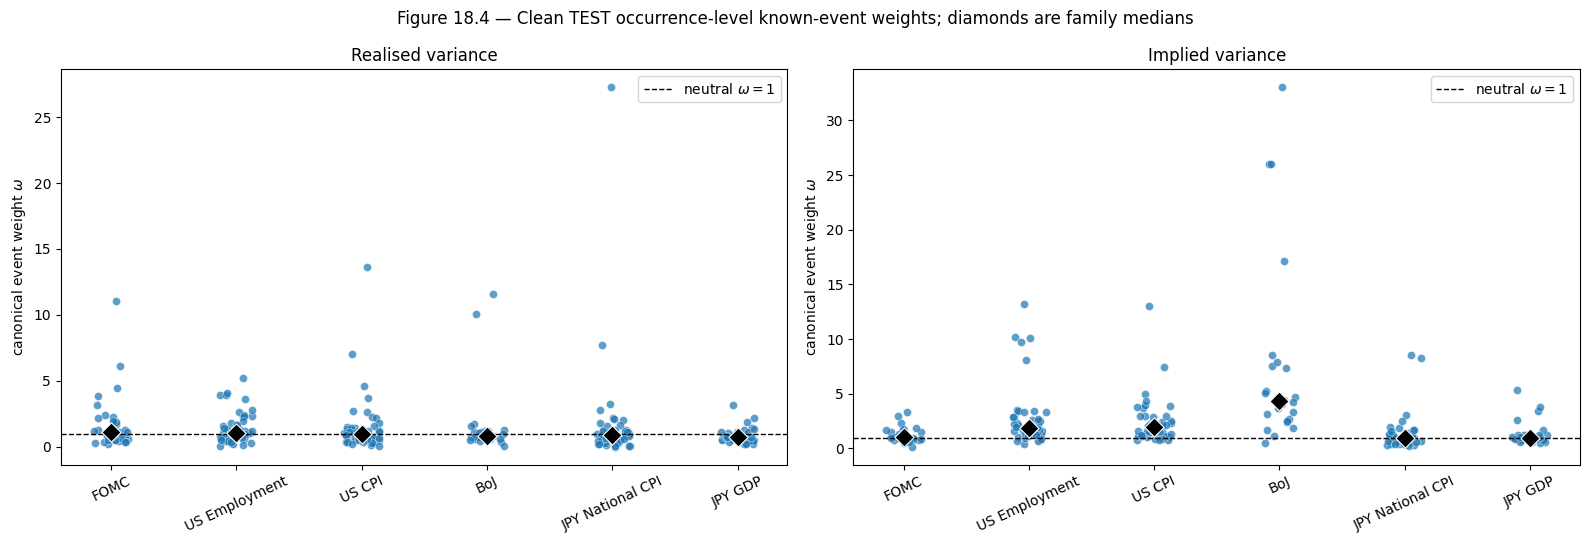

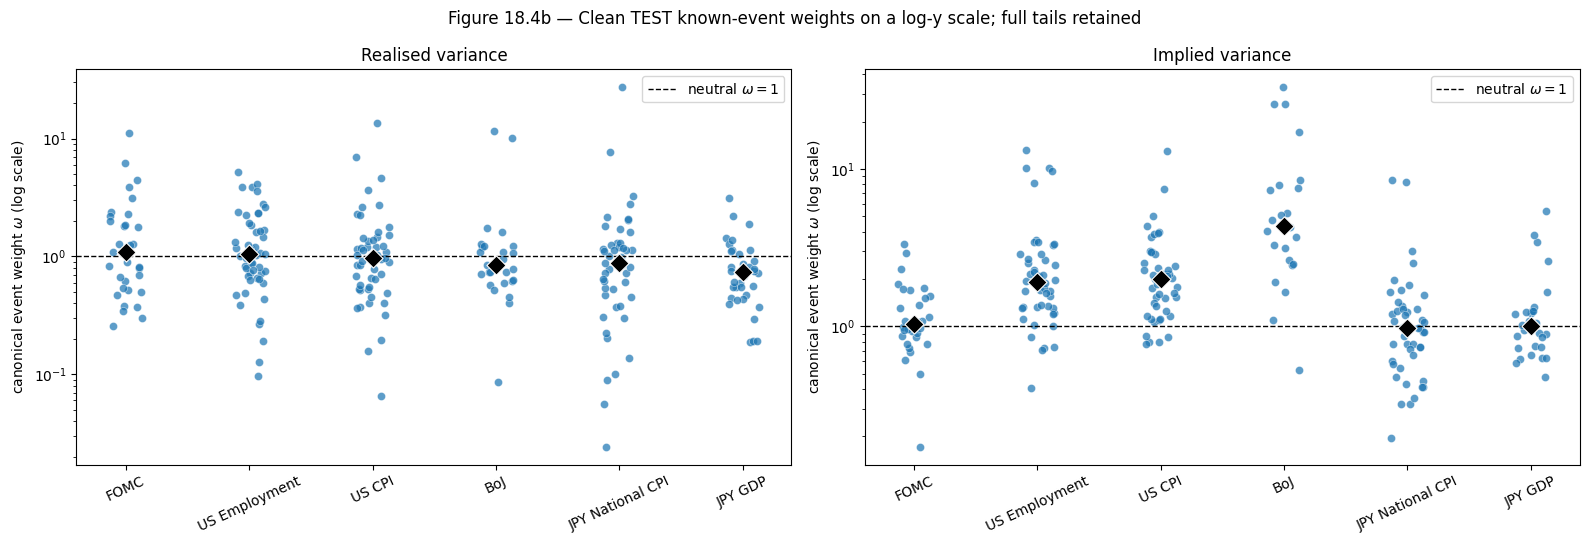

,family,target,sample,n_occurrences,n_equation_eligible,n_canonical_weights_defined,median_event_weight,mean_event_weight,std_event_weight,variance_event_weight,q05_event_weight,q25_event_weight,q75_event_weight,iqr_event_weight,q95_event_weight,minimum_event_weight,maximum_event_weight,fraction_omega_gt_1,fraction_omega_lt_1,n_floor_activated,floor_activation_fraction
0,BoJ,I,PRIMARY_CLEAN_TEST,24,24,24,4.365182,7.687264,8.756169,76.670502,1.186048,2.608907,7.637476,5.028569,26.046047,0.524044,33.032381,0.958333,0.041667,3,0.125000
1,BoJ,R,PRIMARY_CLEAN_TEST,27,27,27,0.840995,1.609328,2.695926,7.268016,0.420027,0.623537,1.210719,0.587183,7.573560,0.085478,11.621737,0.407407,0.592593,0,0.000000
2,FOMC,I,PRIMARY_CLEAN_TEST,32,30,30,1.033527,1.246862,0.687184,0.472222,0.546231,0.857873,1.541136,0.683263,2.658649,0.171970,3.340444,0.500000,0.500000,1,0.033333
3,FOMC,R,PRIMARY_CLEAN_TEST,34,33,33,1.096284,1.759354,2.134790,4.557330,0.324521,0.539178,1.991330,1.452152,5.158784,0.258398,11.064626,0.515152,0.484848,0,0.000000
4,JPY GDP,I,PRIMARY_CLEAN_TEST,35,30,30,0.999016,1.328172,1.090819,1.189886,0.601892,0.743667,1.241228,0.497561,3.656831,0.473309,5.366693,0.500000,0.500000,3,0.100000
5,JPY GDP,R,PRIMARY_CLEAN_TEST,36,36,36,0.738869,0.843702,0.596610,0.355944,0.191237,0.460450,1.059043,0.598593,1.952965,0.188826,3.149158,0.277778,0.722222,0,0.000000
6,JPY National CPI,I,PRIMARY_CLEAN_TEST,48,45,45,0.973431,1.344738,1.646590,2.711259,0.327916,0.603256,1.292193,0.688937,2.920026,0.194834,8.545246,0.444444,0.555556,4,0.088889
7,JPY National CPI,R,PRIMARY_CLEAN_TEST,48,47,47,0.874171,1.662732,4.001015,16.008124,0.092340,0.459719,1.276556,0.816836,3.115553,0.024335,27.252296,0.446809,0.553191,0,0.000000
8,US CPI,I,PRIMARY_CLEAN_TEST,52,45,45,1.998864,2.429843,2.077368,4.315456,0.808663,1.245535,2.884773,1.639238,4.860428,0.772270,13.051126,0.888889,0.111111,2,0.044444
9,US CPI,R,PRIMARY_CLEAN_TEST,51,51,51,0.972722,1.480346,2.107666,4.442257,0.257048,0.537986,1.403359,0.865373,4.144598,0.065094,13.655224,0.490196,0.509804,0,0.000000


In [46]:
known_event_distribution_rows = []
for (family, target), group in primary_clean_test_weights.groupby(["family", "target"], sort=True):
    values = group.loc[group["weight_defined"], "event_weight"].to_numpy(dtype=float)
    known_event_distribution_rows.append({
        "family": family,
        "target": target,
        "sample": "PRIMARY_CLEAN_TEST",
        "n_occurrences": int(len(group)),
        "n_equation_eligible": int(group["equation_eligible"].sum()),
        "n_canonical_weights_defined": int(len(values)),
        "median_event_weight": float(np.median(values)) if len(values) else np.nan,
        "mean_event_weight": float(np.mean(values)) if len(values) else np.nan,
        "std_event_weight": float(np.std(values, ddof=1)) if len(values) >= 2 else np.nan,
        "variance_event_weight": float(np.var(values, ddof=1)) if len(values) >= 2 else np.nan,
        "q05_event_weight": float(np.quantile(values, .05)) if len(values) else np.nan,
        "q25_event_weight": float(np.quantile(values, .25)) if len(values) else np.nan,
        "q75_event_weight": float(np.quantile(values, .75)) if len(values) else np.nan,
        "iqr_event_weight": float(np.quantile(values, .75) - np.quantile(values, .25)) if len(values) else np.nan,
        "q95_event_weight": float(np.quantile(values, .95)) if len(values) else np.nan,
        "minimum_event_weight": float(np.min(values)) if len(values) else np.nan,
        "maximum_event_weight": float(np.max(values)) if len(values) else np.nan,
        "fraction_omega_gt_1": float(np.mean(values > 1)) if len(values) else np.nan,
        "fraction_omega_lt_1": float(np.mean(values < 1)) if len(values) else np.nan,
        "n_floor_activated": int(group["floor_activated"].sum()),
        "floor_activation_fraction": float(group["floor_activated"].mean()) if len(group) else np.nan,
    })
known_event_weight_distribution_summary = pd.DataFrame(known_event_distribution_rows)
assert len(known_event_weight_distribution_summary) == 12
assert set(known_event_weight_distribution_summary["family"]) == set(FAMILY_LABELS)

FIGURES.mkdir(parents=True, exist_ok=True)
figure_18_4_path = FIGURES / "18_figure_18_4_known_event_weight_distributions.png"
families = list(FAMILY_LABELS)
jitter_rng = np.random.default_rng(18)
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=False)
for axis, target, title in zip(axes, ["R", "I"], ["Realised variance", "Implied variance"]):
    target_rows = primary_clean_test_weights.loc[
        primary_clean_test_weights["target"].eq(target) & primary_clean_test_weights["weight_defined"]
    ]
    for position, family in enumerate(families):
        values = target_rows.loc[target_rows["family"].eq(family), "event_weight"].to_numpy(dtype=float)
        x = position + jitter_rng.uniform(-.14, .14, size=len(values))
        axis.scatter(x, values, s=34, alpha=.72, color="tab:blue", edgecolor="white", linewidth=.35)
        if len(values):
            axis.scatter(position, np.median(values), s=95, marker="D", color="black", edgecolor="white", linewidth=.8, zorder=4)
    axis.axhline(1, color="black", linestyle="--", linewidth=1, label="neutral $\\omega=1$")
    axis.set(xticks=np.arange(len(families)), xticklabels=families, ylabel="canonical event weight $\\omega$", title=title)
    axis.tick_params(axis="x", rotation=25)
    axis.legend(loc="best")
fig.suptitle("Figure 18.4 — Clean TEST occurrence-level known-event weights; diamonds are family medians")
fig.tight_layout()
fig.savefig(figure_18_4_path, dpi=180)
plt.show()

figure_18_4_log_path = FIGURES / "18_figure_18_4_known_event_weight_distributions_log_y.png"
assert primary_clean_test_weights.loc[primary_clean_test_weights["weight_defined"], "event_weight"].gt(0).all()
log_jitter_rng = np.random.default_rng(1804)
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=False)
for axis, target, title in zip(axes, ["R", "I"], ["Realised variance", "Implied variance"]):
    target_rows = primary_clean_test_weights.loc[primary_clean_test_weights["target"].eq(target) & primary_clean_test_weights["weight_defined"]]
    for position, family in enumerate(families):
        values = target_rows.loc[target_rows["family"].eq(family), "event_weight"].to_numpy(dtype=float)
        axis.scatter(position + log_jitter_rng.uniform(-.14, .14, size=len(values)), values, s=34, alpha=.72, color="tab:blue", edgecolor="white", linewidth=.35)
        if len(values):
            axis.scatter(position, np.median(values), s=95, marker="D", color="black", edgecolor="white", linewidth=.8, zorder=4)
    axis.axhline(1, color="black", linestyle="--", linewidth=1, label="neutral $\\omega=1$")
    axis.set(xticks=np.arange(len(families)), xticklabels=families, yscale="log", ylabel="canonical event weight $\\omega$ (log scale)", title=title)
    axis.tick_params(axis="x", rotation=25)
    axis.legend(loc="best")
fig.suptitle("Figure 18.4b — Clean TEST known-event weights on a log-y scale; full tails retained")
fig.tight_layout()
fig.savefig(figure_18_4_log_path, dpi=180)
plt.show()
display(known_event_weight_distribution_summary)


## 17. Periodic-event benchmark: month-end

The six scheduled macro-event families provide economically labelled responses but some have relatively few clean TEST occurrences. Month-end is a mechanically defined repeated periodic benchmark: the final observed canonical model day in each calendar year-month. It is not a seventh primary event family and does not enter any six-family flag, pooled result, or downstream contract.

Month-end backgrounds use the unchanged frozen N16 parametric equations after masking only calibration targets that are either a primary six-family event target or a month-end target. Lags remain constructed on the intact chronology before this masking. VALIDATION is a pre-TEST repeated-event reference and TEST is a held-out distributional check; neither split is used to select equations, floors, thresholds, or the month-end definition.

For every equation-eligible month-end, $\omega=1$ means observed target equals estimated admissible eventless background. This is a neutral multiplicative reference, not a statistical-significance threshold.


In [47]:
panel["calendar_year_month"] = panel["model_day"].dt.to_period("M")
panel["is_month_end"] = panel["model_day"].eq(panel.groupby("calendar_year_month")["model_day"].transform("max"))
assert panel.groupby("calendar_year_month")["is_month_end"].sum().eq(1).all()
assert panel.loc[panel["is_month_end"]].groupby("calendar_year_month")["model_day"].max().eq(panel.groupby("calendar_year_month")["model_day"].max()).all()
assert panel.loc[panel["is_month_end"], "model_day"].dt.to_period("M").equals(panel.loc[panel["is_month_end"], "calendar_year_month"])
panel["R_month_end_overlaps_primary_event"] = panel["R_is_target_event_day"].eq(True)
panel["I_month_end_overlaps_primary_event"] = panel["I_is_target_event_day"].eq(True)

def fit_month_end_eventless(target, splits, calibration_stage):
    features = R_FEATURES if target == "R" else I_FEATURES
    sample = panel.loc[
        panel["sample_split"].isin(splits)
        & panel[f"{target}_base_eligible"]
        & ~panel[f"{target}_is_target_event_day"]
        & ~panel["is_month_end"]
    ].copy()
    assert not sample["is_month_end"].any()
    assert not sample[f"{target}_is_target_event_day"].any()
    fit = sm.OLS(sample[target], sm.add_constant(sample[features], has_constant="add")).fit()
    return {"target": target, "features": features, "sample": sample, "fit": fit, "calibration_stage": calibration_stage}

def forecast_month_end_background(model, split, forecast_stage):
    target, features = model["target"], model["features"]
    rows = panel.loc[panel["sample_split"].eq(split) & panel[f"{target}_base_eligible"]].copy()
    rows["raw_background_forecast"] = model["fit"].predict(sm.add_constant(rows[features], has_constant="add"))
    rows["admissible_background_forecast"] = np.maximum(rows["raw_background_forecast"], FORECAST_FLOORS[target])
    rows["forecast_floor"] = FORECAST_FLOORS[target]
    rows["floor_activated"] = rows["raw_background_forecast"].lt(rows["forecast_floor"])
    rows["actual"] = rows[target]
    rows["target"] = target
    rows["forecast_stage"] = forecast_stage
    rows["equation_eligible"] = True
    return rows

month_end_validation_models = {target: fit_month_end_eventless(target, ["train"], "TRAIN_MONTH_END_MASKED") for target in ["R", "I"]}
month_end_test_models = {target: fit_month_end_eventless(target, ["train", "validation"], "TRAIN_VALIDATION_MONTH_END_MASKED") for target in ["R", "I"]}
assert all(model["sample"]["model_day"].max() < test_start for model in month_end_test_models.values())
month_end_forecasts = pd.concat([
    forecast_month_end_background(month_end_validation_models[target], "validation", "validation_oos_month_end_background") for target in ["R", "I"]
] + [
    forecast_month_end_background(month_end_test_models[target], "test", "test_oos_month_end_background") for target in ["R", "I"]
], ignore_index=True)
month_end_event_weights = month_end_forecasts.loc[month_end_forecasts["is_month_end"]].copy()
month_end_event_weights["split"] = month_end_event_weights["sample_split"]
month_end_event_weights["month_end_overlaps_primary_event"] = np.where(month_end_event_weights["target"].eq("R"), month_end_event_weights["R_month_end_overlaps_primary_event"], month_end_event_weights["I_month_end_overlaps_primary_event"]).astype(bool)
month_end_event_weights["overlap_status"] = np.where(month_end_event_weights["month_end_overlaps_primary_event"], "OVERLAP_PRIMARY_EVENT", "CLEAN_MONTH_END")
month_end_event_weights["raw_weight_defined"] = month_end_event_weights["equation_eligible"] & month_end_event_weights["raw_background_forecast"].gt(0) & np.isfinite(month_end_event_weights["raw_background_forecast"])
month_end_event_weights["weight_defined"] = month_end_event_weights["equation_eligible"] & np.isfinite(month_end_event_weights["admissible_background_forecast"])
month_end_event_weights["omega_month_end_raw"] = np.where(month_end_event_weights["raw_weight_defined"], month_end_event_weights["actual"] / month_end_event_weights["raw_background_forecast"], np.nan)
month_end_event_weights["omega_month_end_adm"] = np.where(month_end_event_weights["weight_defined"], month_end_event_weights["actual"] / month_end_event_weights["admissible_background_forecast"], np.nan)
month_end_event_weights["omega_month_end"] = month_end_event_weights["omega_month_end_adm"]
month_end_event_weights["is_out_of_sample"] = True
month_end_event_weights = month_end_event_weights[[
    "model_day", "target", "sample_split", "split", "forecast_stage", "actual",
    "is_month_end", "month_end_overlaps_primary_event", "overlap_status",
    "raw_background_forecast", "admissible_background_forecast", "forecast_floor",
    "floor_activated", "omega_month_end_raw", "omega_month_end_adm",
    "omega_month_end", "raw_weight_defined", "weight_defined",
    "equation_eligible", "is_out_of_sample",
]]
assert set(month_end_event_weights["sample_split"]) == {"validation", "test"}
assert month_end_event_weights["is_month_end"].all()
assert month_end_event_weights.loc[~month_end_event_weights["raw_weight_defined"], "omega_month_end_raw"].isna().all()
assert np.allclose(month_end_event_weights.loc[month_end_event_weights["weight_defined"], "omega_month_end"], month_end_event_weights.loc[month_end_event_weights["weight_defined"], "actual"] / month_end_event_weights.loc[month_end_event_weights["weight_defined"], "admissible_background_forecast"], rtol=1e-12, atol=1e-14)


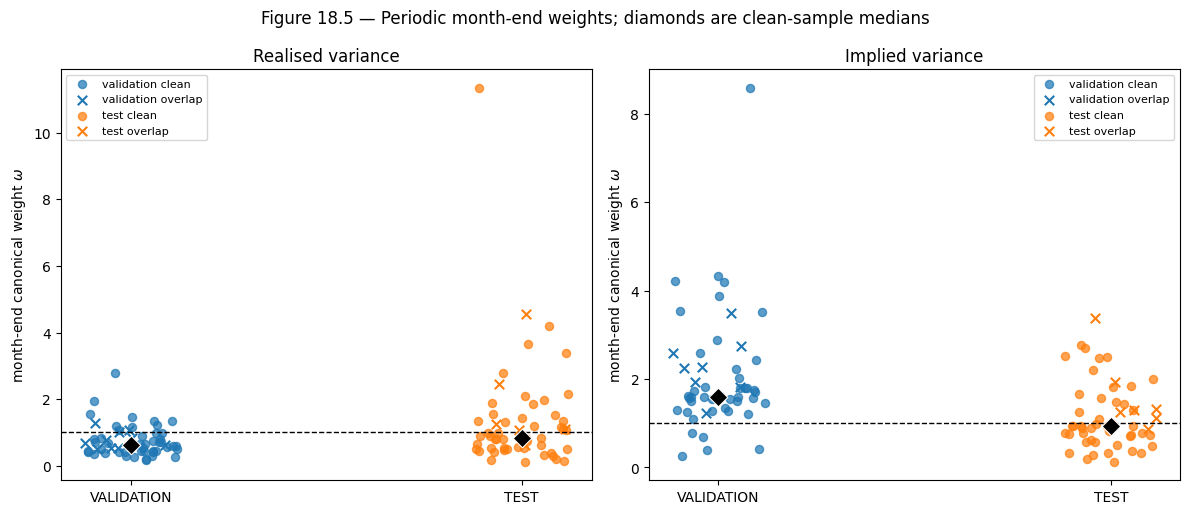

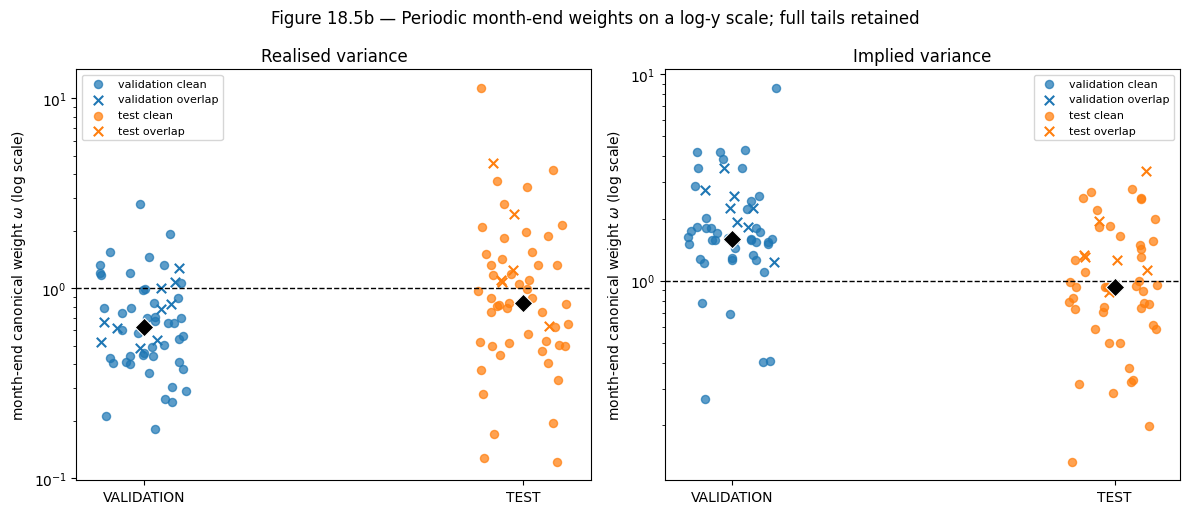

,target,sample_split,overlap_status,n_occurrences,n_equation_eligible,n_canonical_weights_defined,n_raw_weights_defined,median_omega,mean_omega,std_omega,variance_omega,q05_omega,q25_omega,q75_omega,iqr_omega,q95_omega,minimum_omega,maximum_omega,fraction_omega_gt_1,fraction_omega_lt_1,n_floor_activated,floor_activation_rate,bootstrap_median_se,bootstrap_ci_lower,bootstrap_ci_upper,bootstrap_repetitions,bootstrap_seed
0,I,test,CLEAN_MONTH_END,45,45,45,45,0.929633,1.108725,0.716270,0.513043,0.290718,0.610277,1.481608,0.871331,2.508946,0.132994,2.772500,0.377778,0.622222,2,0.044444,0.078452,0.770591,1.001895,10000,18
1,I,test,OVERLAP_PRIMARY_EVENT,7,7,7,7,1.303834,1.603135,0.846943,0.717313,0.953769,1.193424,1.635311,0.441887,2.948177,0.879767,3.380874,0.857143,0.142857,0,0.000000,NaN,NaN,NaN,10000,18
2,I,validation,CLEAN_MONTH_END,44,44,44,41,1.591892,2.006904,1.414620,2.001149,0.452923,1.324923,2.071745,0.746822,4.210202,0.268432,8.577222,0.886364,0.113636,20,0.454545,0.061837,1.539960,1.770383,10000,18
3,I,validation,OVERLAP_PRIMARY_EVENT,8,8,8,7,2.254768,2.289299,0.677127,0.458501,1.440563,1.901494,2.620709,0.719215,3.232761,1.234871,3.495645,1.000000,0.000000,2,0.250000,NaN,NaN,NaN,10000,18
4,R,test,CLEAN_MONTH_END,50,50,50,50,0.833816,1.310266,1.701894,2.896443,0.181943,0.506598,1.409536,0.902937,3.542274,0.122368,11.344192,0.400000,0.600000,0,0.000000,0.105291,0.648673,1.115198,10000,18
5,R,test,OVERLAP_PRIMARY_EVENT,6,6,6,6,1.177465,1.850978,1.464856,2.145802,0.747612,1.090433,2.160697,1.070264,4.040662,0.635642,4.565436,0.833333,0.166667,0,0.000000,NaN,NaN,NaN,10000,18
6,R,validation,CLEAN_MONTH_END,46,46,46,46,0.629469,0.749867,0.500299,0.250299,0.254714,0.415132,0.954327,0.539195,1.531972,0.181228,2.791646,0.217391,0.782609,0,0.000000,0.072476,0.470183,0.744148,10000,18
7,R,validation,OVERLAP_PRIMARY_EVENT,10,10,10,10,0.724144,0.780866,0.268958,0.072338,0.500832,0.556910,0.962477,0.405567,1.192786,0.486110,1.282347,0.300000,0.700000,0,0.000000,NaN,NaN,NaN,10000,18


,periodic_benchmark,periodic_benchmark_primary_family,month_end_definition,lag_construction_before_masking,six_family_targets_excluded_from_calibration,month_end_targets_excluded_from_calibration,validation_used_for_design,test_used_for_design,frozen_target_floors_reused,event_weights_clipped,target_specific_implied_timing_contract,bloomberg_snapshot_time_identified
0,MONTH_END,False,LAST_OBSERVED_CANONICAL_MODEL_DAY_OF_CALENDAR_...,True,True,True,True,False,True,False,True,False


In [48]:
month_end_summary_rows = []
for (target, split, overlap_status), group in month_end_event_weights.groupby(["target", "sample_split", "overlap_status"], sort=True):
    values = group.loc[group["weight_defined"], "omega_month_end"].to_numpy(dtype=float)
    bootstrap_statistics = bootstrap_median_statistics(values) if overlap_status == "CLEAN_MONTH_END" else {"bootstrap_median_se": np.nan, "bootstrap_ci_lower": np.nan, "bootstrap_ci_upper": np.nan}
    month_end_summary_rows.append({
        "target": target, "sample_split": split, "overlap_status": overlap_status,
        "n_occurrences": int(len(group)),
        "n_equation_eligible": int(group["equation_eligible"].sum()),
        "n_canonical_weights_defined": int(len(values)),
        "n_raw_weights_defined": int(group["raw_weight_defined"].sum()),
        "median_omega": float(np.median(values)) if len(values) else np.nan,
        "mean_omega": float(np.mean(values)) if len(values) else np.nan,
        "std_omega": float(np.std(values, ddof=1)) if len(values) >= 2 else np.nan,
        "variance_omega": float(np.var(values, ddof=1)) if len(values) >= 2 else np.nan,
        "q05_omega": float(np.quantile(values, .05)) if len(values) else np.nan,
        "q25_omega": float(np.quantile(values, .25)) if len(values) else np.nan,
        "q75_omega": float(np.quantile(values, .75)) if len(values) else np.nan,
        "iqr_omega": float(np.quantile(values, .75) - np.quantile(values, .25)) if len(values) else np.nan,
        "q95_omega": float(np.quantile(values, .95)) if len(values) else np.nan,
        "minimum_omega": float(np.min(values)) if len(values) else np.nan,
        "maximum_omega": float(np.max(values)) if len(values) else np.nan,
        "fraction_omega_gt_1": float(np.mean(values > 1)) if len(values) else np.nan,
        "fraction_omega_lt_1": float(np.mean(values < 1)) if len(values) else np.nan,
        "n_floor_activated": int(group["floor_activated"].sum()),
        "floor_activation_rate": float(group["floor_activated"].mean()) if len(group) else np.nan,
        **bootstrap_statistics, "bootstrap_repetitions": 10000, "bootstrap_seed": 18,
    })
month_end_weight_summary = pd.DataFrame(month_end_summary_rows)
month_end_weight_bootstrap = month_end_weight_summary.loc[month_end_weight_summary["overlap_status"].eq("CLEAN_MONTH_END"), ["target", "sample_split", "overlap_status", "n_canonical_weights_defined", "median_omega", "bootstrap_median_se", "bootstrap_ci_lower", "bootstrap_ci_upper", "bootstrap_repetitions", "bootstrap_seed"]].copy()
assert set(month_end_weight_summary["sample_split"]) == {"validation", "test"}
assert month_end_weight_bootstrap["bootstrap_repetitions"].eq(10000).all() and month_end_weight_bootstrap["bootstrap_seed"].eq(18).all()
month_end_benchmark_metadata = pd.DataFrame([{
    "periodic_benchmark": "MONTH_END",
    "periodic_benchmark_primary_family": False,
    "month_end_definition": "LAST_OBSERVED_CANONICAL_MODEL_DAY_OF_CALENDAR_MONTH",
    "lag_construction_before_masking": True,
    "six_family_targets_excluded_from_calibration": True,
    "month_end_targets_excluded_from_calibration": True,
    "validation_used_for_design": True,
    "test_used_for_design": False,
    "frozen_target_floors_reused": True,
    "event_weights_clipped": False,
    "target_specific_implied_timing_contract": True,
    "bloomberg_snapshot_time_identified": False,
}])
figure_18_5_path = FIGURES / "18_figure_18_5_month_end_weight_distributions.png"
month_end_jitter = np.random.default_rng(1818)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharey=False)
for axis, target, title in zip(axes, ["R", "I"], ["Realised variance", "Implied variance"]):
    target_rows = month_end_event_weights.loc[month_end_event_weights["target"].eq(target) & month_end_event_weights["weight_defined"]]
    for position, split, color in [(0, "validation", "tab:blue"), (1, "test", "tab:orange")]:
        clean = target_rows.loc[target_rows["sample_split"].eq(split) & target_rows["overlap_status"].eq("CLEAN_MONTH_END"), "omega_month_end"].to_numpy(dtype=float)
        overlap = target_rows.loc[target_rows["sample_split"].eq(split) & target_rows["overlap_status"].eq("OVERLAP_PRIMARY_EVENT"), "omega_month_end"].to_numpy(dtype=float)
        axis.scatter(position + month_end_jitter.uniform(-.12, .12, size=len(clean)), clean, color=color, alpha=.72, s=34, label=f"{split} clean")
        axis.scatter(position + month_end_jitter.uniform(-.12, .12, size=len(overlap)), overlap, color=color, marker="x", s=46, label=f"{split} overlap")
        if len(clean):
            axis.scatter(position, np.median(clean), marker="D", s=90, color="black", edgecolor="white", linewidth=.8, zorder=4)
    axis.axhline(1, color="black", linestyle="--", linewidth=1)
    axis.set(xticks=[0, 1], xticklabels=["VALIDATION", "TEST"], ylabel="month-end canonical weight $\\omega$", title=title)
    handles, labels = axis.get_legend_handles_labels()
    axis.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys(), fontsize=8)
fig.suptitle("Figure 18.5 — Periodic month-end weights; diamonds are clean-sample medians")
fig.tight_layout()
fig.savefig(figure_18_5_path, dpi=180)
plt.show()

figure_18_5_log_path = FIGURES / "18_figure_18_5_month_end_weight_distributions_log_y.png"
assert month_end_event_weights.loc[month_end_event_weights["weight_defined"], "omega_month_end"].gt(0).all()
month_end_log_jitter = np.random.default_rng(1819)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharey=False)
for axis, target, title in zip(axes, ["R", "I"], ["Realised variance", "Implied variance"]):
    target_rows = month_end_event_weights.loc[month_end_event_weights["target"].eq(target) & month_end_event_weights["weight_defined"]]
    for position, split, color in [(0, "validation", "tab:blue"), (1, "test", "tab:orange")]:
        clean = target_rows.loc[target_rows["sample_split"].eq(split) & target_rows["overlap_status"].eq("CLEAN_MONTH_END"), "omega_month_end"].to_numpy(dtype=float)
        overlap = target_rows.loc[target_rows["sample_split"].eq(split) & target_rows["overlap_status"].eq("OVERLAP_PRIMARY_EVENT"), "omega_month_end"].to_numpy(dtype=float)
        axis.scatter(position + month_end_log_jitter.uniform(-.12, .12, size=len(clean)), clean, color=color, alpha=.72, s=34, label=f"{split} clean")
        axis.scatter(position + month_end_log_jitter.uniform(-.12, .12, size=len(overlap)), overlap, color=color, marker="x", s=46, label=f"{split} overlap")
        if len(clean):
            axis.scatter(position, np.median(clean), marker="D", s=90, color="black", edgecolor="white", linewidth=.8, zorder=4)
    axis.axhline(1, color="black", linestyle="--", linewidth=1)
    axis.set(xticks=[0, 1], xticklabels=["VALIDATION", "TEST"], yscale="log", ylabel="month-end canonical weight $\\omega$ (log scale)", title=title)
    handles, labels = axis.get_legend_handles_labels()
    axis.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys(), fontsize=8)
fig.suptitle("Figure 18.5b — Periodic month-end weights on a log-y scale; full tails retained")
fig.tight_layout()
fig.savefig(figure_18_5_log_path, dpi=180)
plt.show()
display(month_end_weight_summary)
display(month_end_benchmark_metadata)


## Supplementary BoJ policy-rate-regime diagnostic

The all-BoJ pooled response ratio remains the canonical primary result. This supplementary breakdown attaches audited policy-rate metadata to the unchanged Bloomberg G10 BoJ occurrences; it neither changes occurrence dates/timestamps nor uses response ratios to choose regime boundaries. A below-one all-BoJ ratio means that the observed state was below its target-specific eventless background for the typical pooled occurrence, not that BoJ decisions reduce volatility. BoJ events span heterogeneous monetary-policy environments, which motivates this descriptive regime view.

Regimes are defined mechanically from the policy-rate sign: NEGATIVE_RATE for a negative rate, ZERO_RATE for a zero rate, POSITIVE_RATE for a positive rate, and UNKNOWN_RATE when no audited metadata are available. The coverage table reports the historical canonical BoJ match rate separately from the primary clean TEST BoJ match rate. Limited historical coverage constrains extension across the full sample, while complete primary-TEST coverage, if shown by the calculation, supports the reported supplementary regime comparison. Low-support groups remain visible and are not overinterpreted.

In [49]:
BOJ_CALENDAR_PATH = INTERIM / "boj_calendar_audited.csv"
assert BOJ_CALENDAR_PATH.exists(), f"Missing supplementary metadata: {BOJ_CALENDAR_PATH}"
boj_calendar = pd.read_csv(BOJ_CALENDAR_PATH)
boj_decisions = boj_calendar.loc[
    boj_calendar["Event"].eq("BoJ Interest Rate Decision")
].copy()
boj_decisions["local_calendar_date"] = pd.to_datetime(
    boj_decisions["local_calendar_date"], errors="coerce"
).dt.normalize()
actual_text = boj_decisions["Actual"].astype(str).str.strip()
rate_text = actual_text.str.extract(
    r"^([+-]?(?:\d+(?:\.\d*)?|\.\d+))\s*%$",
    expand=False,
)
boj_decisions["boj_policy_rate_pct"] = pd.to_numeric(
    rate_text, errors="coerce"
)
valid_boj_rates = boj_decisions.loc[
    boj_decisions["boj_policy_rate_pct"].notna(),
    ["local_calendar_date", "boj_policy_rate_pct"],
].copy()
rate_conflicts = valid_boj_rates.groupby("local_calendar_date")[
    "boj_policy_rate_pct"
].nunique()
assert rate_conflicts.le(1).all(), "Conflicting valid BoJ policy rates on one local date"
boj_rate_metadata = valid_boj_rates.drop_duplicates(
    "local_calendar_date"
).copy()

canonical_boj_occurrences = occurrences.loc[
    occurrences["family"].eq("BoJ")
].copy()
canonical_boj_occurrences["local_calendar_date"] = pd.to_datetime(
    canonical_boj_occurrences["realised_model_day"]
).dt.normalize()
boj_policy_regime_mapping = canonical_boj_occurrences.merge(
    boj_rate_metadata,
    on="local_calendar_date",
    how="left",
    validate="one_to_one",
)
rate_tolerance = 1e-12
policy_rate = boj_policy_regime_mapping["boj_policy_rate_pct"]
boj_policy_regime_mapping["policy_rate_regime"] = np.select(
    [
        policy_rate.notna() & policy_rate.lt(-rate_tolerance),
        policy_rate.notna() & policy_rate.abs().le(rate_tolerance),
        policy_rate.notna() & policy_rate.gt(rate_tolerance),
    ],
    ["NEGATIVE_RATE", "ZERO_RATE", "POSITIVE_RATE"],
    default="UNKNOWN_RATE",
)
boj_policy_regime_mapping["metadata_match"] = policy_rate.notna()
assert np.array_equal(
    boj_policy_regime_mapping["realised_model_day"].to_numpy(),
    canonical_boj_occurrences["realised_model_day"].to_numpy(),
)
assert np.array_equal(
    boj_policy_regime_mapping["event_timestamp_utc"].to_numpy(),
    canonical_boj_occurrences["event_timestamp_utc"].to_numpy(),
)
assert set(boj_policy_regime_mapping["policy_rate_regime"]).issubset({
    "NEGATIVE_RATE", "ZERO_RATE", "POSITIVE_RATE", "UNKNOWN_RATE",
})

boj_primary_weights = event_weights.loc[
    event_weights["sample_split"].eq("test")
    & event_weights["is_clean_single_family"]
    & event_weights["family"].eq("BoJ")
].merge(
    boj_policy_regime_mapping[
        ["event_id", "boj_policy_rate_pct", "policy_rate_regime", "metadata_match"]
    ],
    on="event_id",
    how="left",
    validate="many_to_one",
)
assert len(boj_primary_weights) == int(
    (event_weights["sample_split"].eq("test")
     & event_weights["is_clean_single_family"]
     & event_weights["family"].eq("BoJ")).sum()
)
assert boj_primary_weights["policy_rate_regime"].notna().all()
primary_clean_boj_events = boj_primary_weights[
    ["event_id", "metadata_match"]
].drop_duplicates("event_id")
boj_regime_coverage = pd.DataFrame([
    {
        "sample": "FULL_CANONICAL_BOJ",
        "n_total_boj_events": int(len(boj_policy_regime_mapping)),
        "n_with_rate_metadata": int(
            boj_policy_regime_mapping["metadata_match"].sum()
        ),
    },
    {
        "sample": "PRIMARY_CLEAN_TEST_BOJ",
        "n_total_boj_events": int(len(primary_clean_boj_events)),
        "n_with_rate_metadata": int(
            primary_clean_boj_events["metadata_match"].sum()
        ),
    },
])
boj_regime_coverage["coverage_fraction"] = (
    boj_regime_coverage["n_with_rate_metadata"]
    / boj_regime_coverage["n_total_boj_events"]
)
boj_regime_coverage["coverage_percent"] = (
    100 * boj_regime_coverage["coverage_fraction"]
)
assert boj_regime_coverage["n_total_boj_events"].gt(0).all()

boj_regime_rows = []
for (regime, target), group in boj_primary_weights.groupby(
    ["policy_rate_regime", "target"], sort=True
):
    valid_weights = group.loc[
        group["weight_defined"], "response_ratio"
    ].to_numpy(dtype=float)
    bootstrap_statistics = bootstrap_median_statistics(valid_weights)
    q25 = float(np.quantile(valid_weights, 0.25)) if len(valid_weights) else np.nan
    median_weight = float(np.median(valid_weights)) if len(valid_weights) else np.nan
    q75 = float(np.quantile(valid_weights, 0.75)) if len(valid_weights) else np.nan
    boj_regime_rows.append({
        "policy_rate_regime": regime,
        "target": target,
        "n_total_occurrences": int(len(group)),
        "n_defined_weights": int(len(valid_weights)),
        "median": median_weight,
        "mean": float(np.mean(valid_weights)) if len(valid_weights) else np.nan,
        "q25": q25,
        "q75": q75,
        "observed_min": float(np.min(valid_weights)) if len(valid_weights) else np.nan,
        "observed_max": float(np.max(valid_weights)) if len(valid_weights) else np.nan,
        **bootstrap_statistics,
        "bootstrap_repetitions": 10000,
        "bootstrap_seed": 18,
        "low_support": bool(len(valid_weights) < 5),
    })
boj_policy_regime_summary = pd.DataFrame(boj_regime_rows)
assert (boj_policy_regime_summary["bootstrap_median_se"].dropna() >= 0).all()
assert (boj_policy_regime_summary["bootstrap_ci_lower"].dropna() <= boj_policy_regime_summary["bootstrap_ci_upper"].dropna()).all()
display(boj_regime_coverage)
display(boj_policy_regime_mapping)
display(boj_policy_regime_summary)


,sample,n_total_boj_events,n_with_rate_metadata,coverage_fraction,coverage_percent
0,FULL_CANONICAL_BOJ,221,99,0.447964,44.79638
1,PRIMARY_CLEAN_TEST_BOJ,29,29,1.000000,100.00000


,family,realised_model_day,raw_row_count,raw_labels,n_unique_raw_timestamps,first_event_time_utc,last_event_time_utc,event_timestamp_original,release_span_seconds,event_id,event_label,event_timestamp_utc,event_timestamp_ny,realised_event_offset,implied_event_offset,timing_evidence_basis,realised_canonical_row,implied_canonical_row,implied_model_day,implied_shift_model_days,post_event_hours_to_model_day_close,realised_target_day_available,implied_target_day_available,realised_sample_split,implied_sample_split,model_day,model_day_role,sample_split,R_n_target_occurrences,R_n_target_families,R_family_set,R_is_clean_single_family,R_is_overlap,I_n_target_occurrences,I_n_target_families,I_family_set,I_is_clean_single_family,I_is_overlap,n_target_families,family_set,is_clean_single_family,is_overlap,local_calendar_date,boj_policy_rate_pct,policy_rate_regime,metadata_match
0,BoJ,2006-08-11,1,BOJ Target Rate,1,2006-08-11 04:17:00+00:00,2006-08-11 04:17:00+00:00,2006-08-11 04:17:00+00:00,0.0,BoJ__20060811,BoJ,2006-08-11 04:17:00+00:00,2006-08-11 00:17:00-04:00,0,-1,DIRECT_EVIDENCE,854,853,2006-08-10,-1,16.716667,True,True,train,train,2006-08-11,REALISED_SESSION_CONTAINMENT_LEGACY_ALIAS,train,2,2,BoJ | JPY GDP,False,True,2,2,BoJ | JPY GDP,False,True,2,BoJ | JPY GDP,False,True,2006-08-11,NaN,UNKNOWN_RATE,False
1,BoJ,2006-09-08,1,BOJ Target Rate,1,2006-09-08 04:37:00+00:00,2006-09-08 04:37:00+00:00,2006-09-08 04:37:00+00:00,0.0,BoJ__20060908,BoJ,2006-09-08 04:37:00+00:00,2006-09-08 00:37:00-04:00,0,-1,DIRECT_EVIDENCE,874,873,2006-09-07,-1,16.383333,True,True,train,train,2006-09-08,REALISED_SESSION_CONTAINMENT_LEGACY_ALIAS,train,1,1,BoJ,True,False,1,1,BoJ,True,False,1,BoJ,True,False,2006-09-08,NaN,UNKNOWN_RATE,False
2,BoJ,2006-10-13,1,BOJ Target Rate,1,2006-10-13 04:47:00+00:00,2006-10-13 04:47:00+00:00,2006-10-13 04:47:00+00:00,0.0,BoJ__20061013,BoJ,2006-10-13 04:47:00+00:00,2006-10-13 00:47:00-04:00,0,-1,DIRECT_EVIDENCE,899,898,2006-10-12,-1,16.216667,True,True,train,train,2006-10-13,REALISED_SESSION_CONTAINMENT_LEGACY_ALIAS,train,1,1,BoJ,True,False,1,1,BoJ,True,False,1,BoJ,True,False,2006-10-13,NaN,UNKNOWN_RATE,False
3,BoJ,2006-10-31,1,BOJ Target Rate,1,2006-10-31 03:47:00+00:00,2006-10-31 03:47:00+00:00,2006-10-31 03:47:00+00:00,0.0,BoJ__20061031,BoJ,2006-10-31 03:47:00+00:00,2006-10-30 22:47:00-05:00,0,-1,DIRECT_EVIDENCE,911,910,2006-10-30,-1,18.216667,True,True,train,train,2006-10-31,REALISED_SESSION_CONTAINMENT_LEGACY_ALIAS,train,1,1,BoJ,True,False,1,1,BoJ,True,False,1,BoJ,True,False,2006-10-31,NaN,UNKNOWN_RATE,False
4,BoJ,2006-11-16,1,BOJ Target Rate,1,2006-11-16 03:24:00+00:00,2006-11-16 03:24:00+00:00,2006-11-16 03:24:00+00:00,0.0,BoJ__20061116,BoJ,2006-11-16 03:24:00+00:00,2006-11-15 22:24:00-05:00,0,-1,DIRECT_EVIDENCE,923,922,2006-11-15,-1,18.600000,True,True,train,train,2006-11-16,REALISED_SESSION_CONTAINMENT_LEGACY_ALIAS,train,2,2,BoJ | US CPI,False,True,2,2,BoJ | US CPI,False,True,2,BoJ | US CPI,False,True,2006-11-16,NaN,UNKNOWN_RATE,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216,BoJ,2025-12-19,1,BOJ Target Rate,1,2025-12-19 03:19:00+00:00,2025-12-19 03:19:00+00:00,2025-12-19 03:19:00+00:00,0.0,BoJ__20251219,BoJ,2025-12-19 03:19:00+00:00,2025-12-18 22:19:00-05:00,0,-1,DIRECT_EVIDENCE,5904,5903,2025-12-18,-1,18.683333,True,True,test,test,2025-12-19,REALISED_SESSION_CONTAINMENT_LEGACY_ALIAS,test,2,2,BoJ | JPY National CPI,False,True,2,2,BoJ | JPY National CPI,False,True,2,BoJ | JPY National CPI,False,True,2025-12-19,0.75,POSITIVE_RATE,True
217,BoJ,2026-01-23,1,BOJ Target Rate,1,2026-01-23 03:07:00+00:00,2026-01-23 03:07:00+00:00,2026-01-23 03:07:00+00:00,0.0,BoJ__20260123,BoJ,2026-01-23 03:07:00+00:00,2026-01-22 22:07:00-05:00,0,-1,DIRECT_EVIDENCE,5929,5928,2026-01-22,-1,18.883333,True,True,test,test,2026-01-23,REALISED_SESSION_CONTAINMENT_LEGACY_ALIAS,test,2,2,BoJ | JPY National 

,policy_rate_regime,target,n_total_occurrences,n_defined_weights,median,mean,q25,q75,observed_min,observed_max,bootstrap_median_se,bootstrap_ci_lower,bootstrap_ci_upper,bootstrap_repetitions,bootstrap_seed,low_support
0,NEGATIVE_RATE,I,14,14,6.055675,9.873984,3.289528,8.400907,0.524044,33.032381,2.421271,3.145857,8.550209,10000,18,False
1,NEGATIVE_RATE,R,15,15,0.840995,2.232894,0.671121,1.252617,0.406164,11.621737,0.210060,0.715336,1.276903,10000,18,False
2,POSITIVE_RATE,I,10,10,3.663890,4.625857,2.051401,4.869914,1.102736,17.177413,0.927572,1.908438,5.074502,10000,18,False
3,POSITIVE_RATE,R,12,12,0.811533,0.829871,0.575010,1.077983,0.085478,1.597461,0.133729,0.556651,1.084283,10000,18,False


## Compact TEST figures

Figure 18.1 displays observed targets against admissible eventless backgrounds. Figure 18.2 displays canonical admissible event-response weights: observed occurrence ranges in Panel A and 95% percentile-bootstrap intervals for family medians in Panel B. No event ratio is clipped, winsorised, or re-referenced.


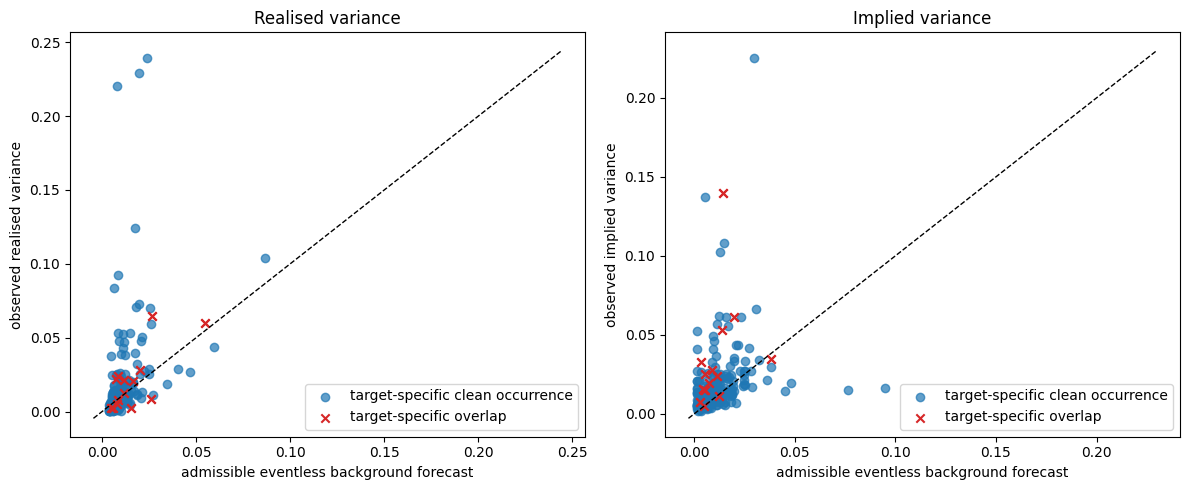

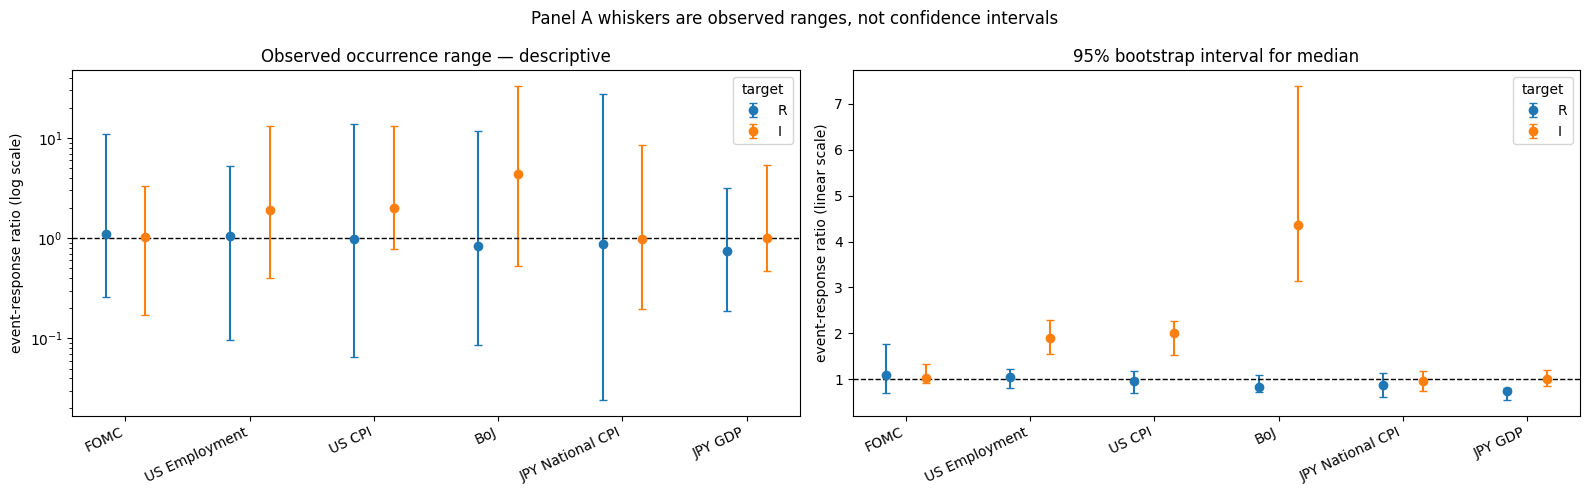

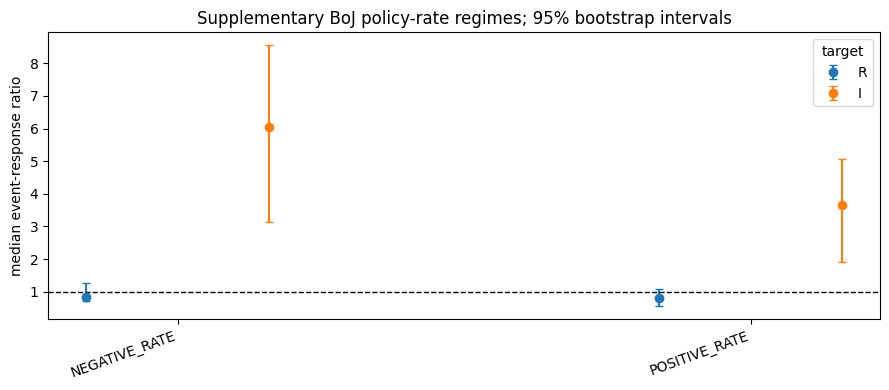

In [50]:
FIGURES.mkdir(parents=True, exist_ok=True)
figure_18_1_path = FIGURES / "18_figure_18_1_event_variance_vs_background.png"
figure_18_2_path = FIGURES / "18_figure_18_2_pooled_event_response_ratios.png"
figure_18_3_path = FIGURES / "18_figure_18_3_boj_policy_regime_response_ratios.png"
for figure_path in [figure_18_1_path, figure_18_2_path, figure_18_3_path]:
    if figure_path.exists():
        assert figure_path.is_file()
        figure_path.unlink()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for axis, target, label in zip(
    axes, ["R", "I"], ["Realised variance", "Implied variance"]
):
    plot_data = event_weights.loc[
        event_weights["sample_split"].eq("test")
        & event_weights["target"].eq(target)
        & event_weights["equation_eligible"]
    ].copy()
    clean = plot_data.loc[plot_data["is_clean_single_family"]]
    overlap = plot_data.loc[plot_data["is_overlap"]]
    axis.scatter(
        clean["admissible_background_forecast"], clean["actual"],
        alpha=0.7, label="target-specific clean occurrence",
    )
    axis.scatter(
        overlap["admissible_background_forecast"], overlap["actual"],
        marker="x", color="tab:red", label="target-specific overlap",
    )
    plot_min = min(
        plot_data["admissible_background_forecast"].min(),
        plot_data["actual"].min(),
    )
    plot_max = max(
        plot_data["admissible_background_forecast"].max(),
        plot_data["actual"].max(),
    )
    margin = 0.02 * (plot_max - plot_min) if plot_max > plot_min else 0.01
    axis.plot(
        [plot_min - margin, plot_max + margin],
        [plot_min - margin, plot_max + margin],
        "k--", linewidth=1,
    )
    axis.set(
        xlabel="admissible eventless background forecast",
        ylabel=f"observed {label.lower()}",
        title=label,
    )
    axis.legend()
fig.tight_layout()
fig.savefig(
    str(figure_18_1_path),
    dpi=160,
)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
families = list(FAMILY_LABELS)
target_styles = [
    (-0.16, "R", "tab:blue"),
    (0.16, "I", "tab:orange"),
]
panel_specifications = [
    ("Observed occurrence range — descriptive", "observed_min", "observed_max"),
    ("95% bootstrap interval for median", "bootstrap_ci_lower", "bootstrap_ci_upper"),
]
for axis, (title, lower_column, upper_column) in zip(
    axes, panel_specifications
):
    for offset, target, color in target_styles:
        values = (
            table_18_6.loc[table_18_6["target"].eq(target)]
            .set_index("family")
            .reindex(families)
        )
        median_weight = values["median"].to_numpy(float)
        lower = values[lower_column].to_numpy(float)
        upper = values[upper_column].to_numpy(float)
        errors = np.vstack([
            median_weight - lower,
            upper - median_weight,
        ])
        axis.errorbar(
            np.arange(len(families)) + offset,
            median_weight,
            yerr=np.maximum(errors, 0),
            fmt="o",
            capsize=3,
            color=color,
            label=target,
        )
    axis.axhline(1, color="black", linestyle="--", linewidth=1)
    axis.set_title(title)
    axis.set_xticks(np.arange(len(families)), families, rotation=25, ha="right")
    axis.set_ylabel("event-response ratio")
    axis.legend(title="target")
panel_a_range_data = table_18_6[
    ["family", "target", "observed_min", "median", "observed_max"]
].copy()
assert panel_a_range_data["observed_min"].gt(0).all()
assert (panel_a_range_data["observed_min"] <= panel_a_range_data["median"]).all()
assert (panel_a_range_data["median"] <= panel_a_range_data["observed_max"]).all()
axes[0].set_yscale("log")
axes[0].set_ylabel("event-response ratio (log scale)")
axes[1].set_ylabel("event-response ratio (linear scale)")
fig.suptitle("Panel A whiskers are observed ranges, not confidence intervals")
fig.tight_layout()
fig.savefig(
    str(figure_18_2_path),
    dpi=160,
)
plt.show()

regime_support = boj_policy_regime_summary.groupby("policy_rate_regime")[
    "n_defined_weights"
].min()
plot_regimes = regime_support.loc[regime_support.ge(5)].index.tolist()
if len(plot_regimes) >= 2:
    fig, axis = plt.subplots(figsize=(9, 4))
    for offset, target, color in target_styles:
        values = (
            boj_policy_regime_summary.loc[
                boj_policy_regime_summary["target"].eq(target)
                & boj_policy_regime_summary["policy_rate_regime"].isin(plot_regimes)
            ]
            .set_index("policy_rate_regime")
            .reindex(plot_regimes)
        )
        median_weight = values["median"].to_numpy(float)
        errors = np.vstack([
            median_weight - values["bootstrap_ci_lower"].to_numpy(float),
            values["bootstrap_ci_upper"].to_numpy(float) - median_weight,
        ])
        axis.errorbar(
            np.arange(len(plot_regimes)) + offset,
            median_weight,
            yerr=np.maximum(errors, 0),
            fmt="o",
            capsize=3,
            color=color,
            label=target,
        )
    axis.axhline(1, color="black", linestyle="--", linewidth=1)
    axis.set_xticks(np.arange(len(plot_regimes)), plot_regimes, rotation=20, ha="right")
    axis.set_ylabel("median event-response ratio")
    axis.set_title("Supplementary BoJ policy-rate regimes; 95% bootstrap intervals")
    axis.legend(title="target")
    fig.tight_layout()
    fig.savefig(str(figure_18_3_path), dpi=160)
    plt.show()

LINEAR SCALE VERSION


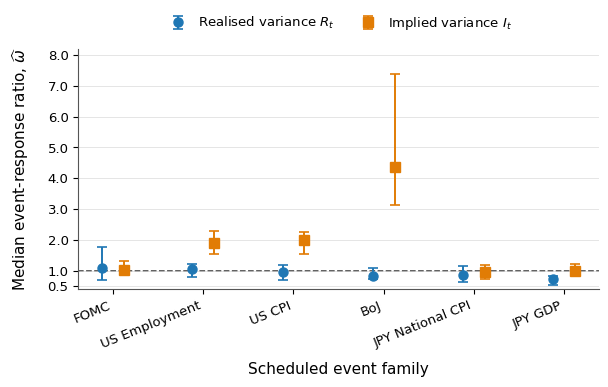

LOG SCALE VERSION


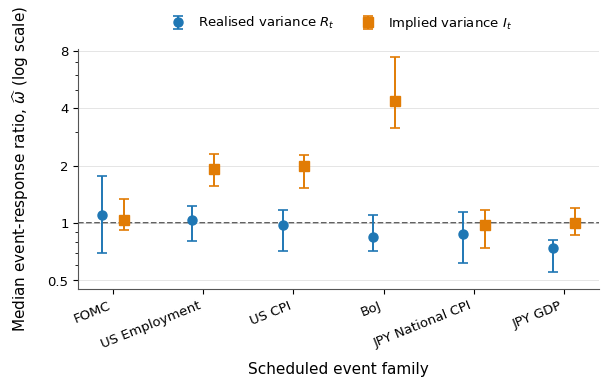


Dissertation figures exported:

Linear:
  PDF: plots\dissertation\fig_5_2_scheduled_event_response_weights_linear.pdf
  PNG: plots\dissertation\fig_5_2_scheduled_event_response_weights_linear.png

Log:
  PDF: plots\dissertation\fig_5_2_scheduled_event_response_weights_log.pdf
  PNG: plots\dissertation\fig_5_2_scheduled_event_response_weights_log.png


In [55]:
# ============================================================
# DISSERTATION FIGURE EXPORT
# Figure 5.2 — Scheduled-event response weights
#
# Produces TWO separate presentation-only versions:
#   1. Linear y-axis
#   2. Logarithmic y-axis
#
# Both use the already-computed `table_18_6`.
# No event weights or bootstrap intervals are recomputed.
# ============================================================

from pathlib import Path
from matplotlib.ticker import FixedLocator, FuncFormatter

# ------------------------------------------------------------
# 1. Output directory
# ------------------------------------------------------------

DISSERTATION_FIG_DIR = PROJECT_ROOT / "plots" / "dissertation"
DISSERTATION_FIG_DIR.mkdir(parents=True, exist_ok=True)

LINEAR_PDF = (
    DISSERTATION_FIG_DIR
    / "fig_5_2_scheduled_event_response_weights_linear.pdf"
)

LINEAR_PNG = (
    DISSERTATION_FIG_DIR
    / "fig_5_2_scheduled_event_response_weights_linear.png"
)

LOG_PDF = (
    DISSERTATION_FIG_DIR
    / "fig_5_2_scheduled_event_response_weights_log.pdf"
)

LOG_PNG = (
    DISSERTATION_FIG_DIR
    / "fig_5_2_scheduled_event_response_weights_log.png"
)

# ------------------------------------------------------------
# 2. Fixed event-family order
# ------------------------------------------------------------

families = [
    "FOMC",
    "US Employment",
    "US CPI",
    "BoJ",
    "JPY National CPI",
    "JPY GDP",
]


# ------------------------------------------------------------
# 3. Presentation settings
#
# Keep the same R / I colours and markers in both figures.
# ------------------------------------------------------------

target_styles = {
    "R": {
        "label": r"Realised variance $R_t$",
        "color": "#1F77B4",
        "marker": "o",
        "offset": -0.12,
    },
    "I": {
        "label": r"Implied variance $I_t$",
        "color": "#E17C05",
        "marker": "s",
        "offset": 0.12,
    },
}


# ------------------------------------------------------------
# 4. Sanity checks
# ------------------------------------------------------------

required_columns = {
    "family",
    "target",
    "median",
    "bootstrap_ci_lower",
    "bootstrap_ci_upper",
}

missing_columns = required_columns.difference(table_18_6.columns)

if missing_columns:
    raise KeyError(
        f"`table_18_6` is missing required columns: {missing_columns}"
    )

assert set(families).issubset(set(table_18_6["family"]))
assert {"R", "I"}.issubset(set(table_18_6["target"]))

plot_check = table_18_6.loc[
    table_18_6["family"].isin(families)
    & table_18_6["target"].isin(["R", "I"])
].copy()

# Required for the log-scale version.
assert plot_check["median"].gt(0).all()
assert plot_check["bootstrap_ci_lower"].gt(0).all()
assert plot_check["bootstrap_ci_upper"].gt(0).all()


# ------------------------------------------------------------
# 5. Common plotting function
# ------------------------------------------------------------

def plot_event_response_weights(
    scale,
    pdf_path,
    png_path,
):
    """
    Create the dissertation scheduled-event response-weight plot.

    Parameters
    ----------
    scale : {"linear", "log"}
        Y-axis scale.
    pdf_path : pathlib.Path
        PDF export path.
    png_path : pathlib.Path
        PNG export path.
    """

    fig, ax = plt.subplots(figsize=(6.3, 3.9))

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    x = np.arange(len(families))

    # --------------------------------------------------------
    # Plot medians + 95% bootstrap intervals
    # --------------------------------------------------------

    for target in ["R", "I"]:

        style = target_styles[target]

        values = (
            table_18_6.loc[
                table_18_6["target"].eq(target)
                & table_18_6["family"].isin(families)
            ]
            .set_index("family")
            .reindex(families)
        )

        median = values["median"].to_numpy(float)
        lower = values["bootstrap_ci_lower"].to_numpy(float)
        upper = values["bootstrap_ci_upper"].to_numpy(float)

        errors = np.vstack(
            [
                median - lower,
                upper - median,
            ]
        )

        ax.errorbar(
            x + style["offset"],
            median,
            yerr=np.maximum(errors, 0),
            fmt=style["marker"],
            markersize=6.5,
            markerfacecolor=style["color"],
            markeredgecolor=style["color"],
            color=style["color"],
            ecolor=style["color"],
            elinewidth=1.4,
            capsize=3.5,
            capthick=1.2,
            linestyle="none",
            label=style["label"],
            zorder=3,
        )

    # --------------------------------------------------------
    # No-response reference
    #
    # omega_hat = 1 means observed variance equals the
    # estimated ordinary background.
    # --------------------------------------------------------

    ax.axhline(
        1.0,
        color="#333333",
        linestyle="--",
        linewidth=1.1,
        zorder=1,
    )

    # --------------------------------------------------------
    # Y-axis scale
    # --------------------------------------------------------

    if scale == "linear":

        ax.set_yscale("linear")

        # Fixed range chosen to include the full frozen
        # bootstrap intervals while retaining comparability.
        ax.set_ylim(0.4, 8.2)

        ax.set_yticks(
            [
                0.5,
                1.0,
                2.0,
                3.0,
                4.0,
                5.0,
                6.0,
                7.0,
                8.0,
            ]
        )

        ylabel = (
            r"Median event-response ratio, "
            r"$\widehat{\omega}$"
        )

    elif scale == "log":

        ax.set_yscale("log")

        log_ticks = [
            0.5,
            1.0,
            2.0,
            4.0,
            8.0,
        ]

        ax.yaxis.set_major_locator(
            FixedLocator(log_ticks)
        )

        ax.yaxis.set_major_formatter(
            FuncFormatter(lambda y, _: f"{y:g}")
        )

        ax.set_ylim(0.45, 8.2)

        ylabel = (
            r"Median event-response ratio, "
            r"$\widehat{\omega}$ (log scale)"
        )

    else:
        raise ValueError(
            "`scale` must be either 'linear' or 'log'."
        )

    # --------------------------------------------------------
    # Axis labels
    # --------------------------------------------------------

    ax.set_xticks(x)

    ax.set_xticklabels(
        families,
        rotation=22,
        ha="right",
        fontsize=9.5,
    )

    ax.set_xlabel(
        "Scheduled event family",
        fontsize=11,
        labelpad=8,
    )

    ax.set_ylabel(
        ylabel,
        fontsize=11,
        labelpad=12,
    )

    ax.tick_params(
        axis="y",
        labelsize=9.5,
    )

    # --------------------------------------------------------
    # Professional styling
    # --------------------------------------------------------

    ax.grid(
        axis="y",
        which="major",
        color="#D9D9D9",
        linewidth=0.7,
        alpha=0.7,
    )

    ax.grid(
        axis="x",
        visible=False,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("#555555")
    ax.spines["bottom"].set_color("#555555")

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    # --------------------------------------------------------
    # Legend
    # --------------------------------------------------------

    ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=2,
        frameon=False,
        fontsize=9.5,
        handletextpad=0.5,
        columnspacing=1.5,
    )

    # No internal title:
    # the LaTeX caption will describe the figure.

    fig.tight_layout()

    fig.subplots_adjust(
        left=0.15,
        top=0.88,
    )

    # --------------------------------------------------------
    # Export
    # --------------------------------------------------------

    fig.savefig(
        pdf_path,
        format="pdf",
        bbox_inches="tight",
    )

    fig.savefig(
        png_path,
        format="png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()


# ============================================================
# 6. Generate LINEAR version
# ============================================================

print("LINEAR SCALE VERSION")

plot_event_response_weights(
    scale="linear",
    pdf_path=LINEAR_PDF,
    png_path=LINEAR_PNG,
)


# ============================================================
# 7. Generate LOG version
# ============================================================

print("LOG SCALE VERSION")

plot_event_response_weights(
    scale="log",
    pdf_path=LOG_PDF,
    png_path=LOG_PNG,
)


# ------------------------------------------------------------
# 8. Confirm exports
# ------------------------------------------------------------

print("\nDissertation figures exported:")

print("\nLinear:")
print(f"  PDF: {LINEAR_PDF}")
print(f"  PNG: {LINEAR_PNG}")

print("\nLog:")
print(f"  PDF: {LOG_PDF}")
print(f"  PNG: {LOG_PNG}")

## Supplementary sensitivity - six-family weights after month-end exclusion

The primary six-family event-response weights above use backgrounds calibrated after excluding the six scheduled event families only.

As a supplementary sensitivity check, this section uses the separate month-end benchmark calibration, which excludes both the six scheduled event-family targets and month-end targets from background fitting. The six scheduled event weights are then recomputed on their original target-specific TEST response dates.

This comparison asks whether treating month-end as an additional recurring event materially changes the previously estimated six-family response pattern. It does not replace the primary six-family estimates and does not affect any downstream analysis.

Supplementary sensitivity — primary six-family medians versus month-end-excluded recalibration


,family,median_primary_R,median_month_end_excluded_R,median_difference_R,relative_change_percent_R,median_primary_I,median_month_end_excluded_I,median_difference_I,relative_change_percent_I
0,FOMC,1.096,1.120,+0.023,+2.14%,1.034,1.011,-0.022,-2.17%
1,US Employment,1.043,1.062,+0.019,+1.81%,1.910,1.929,+0.019,+1.02%
2,US CPI,0.973,1.001,+0.028,+2.91%,1.999,2.031,+0.032,+1.62%
3,BoJ,0.841,0.862,+0.021,+2.44%,4.365,4.409,+0.044,+1.00%
4,JPY National CPI,0.874,0.894,+0.020,+2.27%,0.973,0.981,+0.007,+0.75%
5,JPY GDP,0.739,0.754,+0.015,+2.05%,0.999,0.984,-0.015,-1.54%


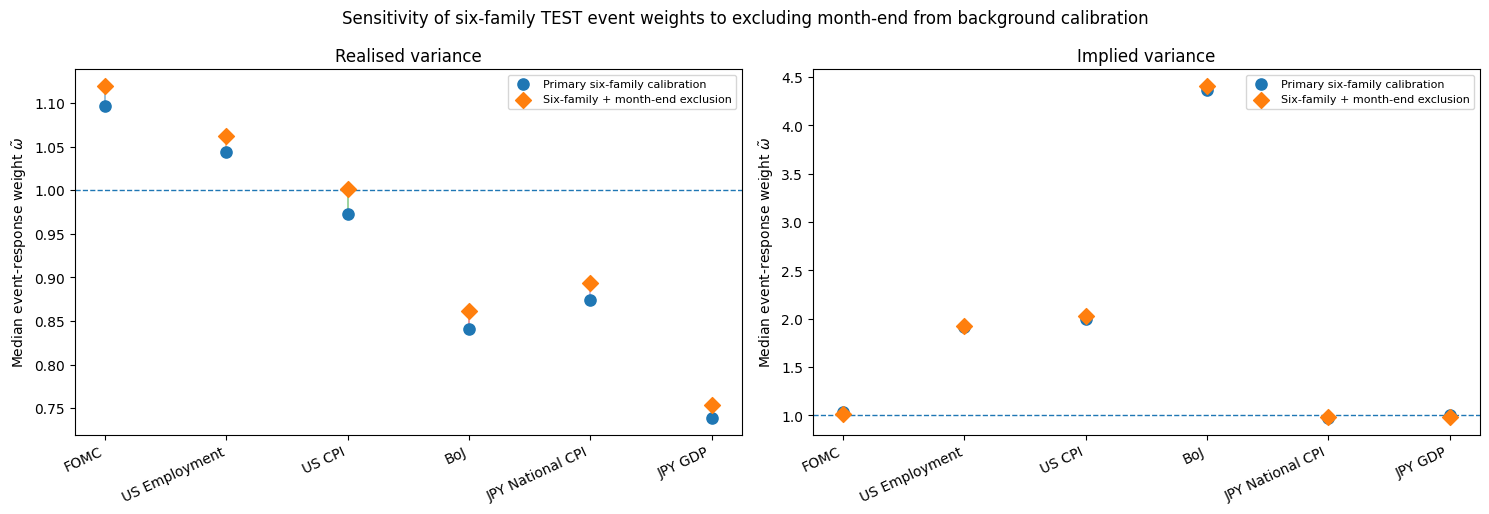

Saved: 18_figure_month_end_exclusion_six_family_sensitivity.png
Saved: 18_month_end_exclusion_six_family_sensitivity.csv


In [56]:
# ============================================================
# Supplementary sensitivity:
# six-family TEST weights under the month-end-excluded background
# ============================================================

# The existing `month_end_forecasts` object was generated from:
#
#   TRAIN / TRAIN+VALIDATION calibration targets excluding:
#       1. the six scheduled event-family target dates, and
#       2. month-end dates.
#
# Here we evaluate the original six event families using that
# alternative background without altering the primary N18 results.


# ------------------------------------------------------------
# 1. Prepare the TEST forecasts from the month-end-excluded fit
# ------------------------------------------------------------

month_end_excluded_test_forecasts = (
    month_end_forecasts.loc[
        month_end_forecasts["sample_split"].eq("test"),
        [
            "model_day",
            "target",
            "actual",
            "raw_background_forecast",
            "admissible_background_forecast",
            "forecast_floor",
            "floor_activated",
            "forecast_stage",
        ],
    ]
    .copy()
    .rename(columns={"model_day": "target_model_day"})
)

assert set(month_end_excluded_test_forecasts["target"]) == {"R", "I"}


# ------------------------------------------------------------
# 2. Map these alternative forecasts onto the ORIGINAL
#    six-family target-specific event dates
# ------------------------------------------------------------

six_family_month_end_sensitivity_weights = (
    target_specific_event_mapping
    .merge(
        month_end_excluded_test_forecasts,
        on=["target_model_day", "target"],
        how="left",
        validate="many_to_one",
    )
    .copy()
)

# Keep TEST events only.
six_family_month_end_sensitivity_weights = (
    six_family_month_end_sensitivity_weights.loc[
        six_family_month_end_sensitivity_weights["sample_split"].eq("test")
    ]
    .copy()
)

# Reconstruct the same admissible-weight definition used by the
# primary N18 six-family analysis.
six_family_month_end_sensitivity_weights["equation_eligible"] = (
    six_family_month_end_sensitivity_weights["actual"].notna()
)

six_family_month_end_sensitivity_weights["weight_defined"] = (
    six_family_month_end_sensitivity_weights["target_model_day_available"]
    & six_family_month_end_sensitivity_weights["equation_eligible"]
    & six_family_month_end_sensitivity_weights[
        "admissible_background_forecast"
    ].notna()
)

six_family_month_end_sensitivity_weights[
    "event_weight_month_end_excluded"
] = np.where(
    six_family_month_end_sensitivity_weights["weight_defined"],
    (
        six_family_month_end_sensitivity_weights["actual"]
        / six_family_month_end_sensitivity_weights[
            "admissible_background_forecast"
        ]
    ),
    np.nan,
)

# The sensitivity check must use the same headline sample definition
# as the primary table: clean, single-family TEST occurrences.
six_family_month_end_sensitivity_clean = (
    six_family_month_end_sensitivity_weights.loc[
        six_family_month_end_sensitivity_weights["is_clean_single_family"]
        & six_family_month_end_sensitivity_weights["weight_defined"]
    ]
    .copy()
)


# ------------------------------------------------------------
# 3. Compute family medians under the alternative calibration
# ------------------------------------------------------------

month_end_excluded_medians = (
    six_family_month_end_sensitivity_clean
    .groupby(["family", "target"], as_index=False)
    .agg(
        n_clean_month_end_excluded=(
            "event_weight_month_end_excluded",
            "size",
        ),
        median_month_end_excluded=(
            "event_weight_month_end_excluded",
            "median",
        ),
    )
)


# ------------------------------------------------------------
# 4. Join with the PRIMARY clean TEST medians from Table 18.6
# ------------------------------------------------------------

primary_medians = (
    table_18_6[
        [
            "family",
            "target",
            "n_defined_weights",
            "median",
        ]
    ]
    .copy()
    .rename(
        columns={
            "n_defined_weights": "n_clean_primary",
            "median": "median_primary",
        }
    )
)

six_family_month_end_sensitivity_summary = (
    primary_medians
    .merge(
        month_end_excluded_medians,
        on=["family", "target"],
        how="outer",
        validate="one_to_one",
    )
)

six_family_month_end_sensitivity_summary["median_difference"] = (
    six_family_month_end_sensitivity_summary[
        "median_month_end_excluded"
    ]
    - six_family_month_end_sensitivity_summary["median_primary"]
)

six_family_month_end_sensitivity_summary["relative_change_percent"] = (
    100
    * (
        six_family_month_end_sensitivity_summary[
            "median_month_end_excluded"
        ]
        / six_family_month_end_sensitivity_summary["median_primary"]
        - 1
    )
)

# Sanity checks: this should still be the same six families × two targets.
assert len(six_family_month_end_sensitivity_summary) == 12
assert set(six_family_month_end_sensitivity_summary["family"]) == set(
    FAMILY_LABELS
)
assert set(six_family_month_end_sensitivity_summary["target"]) == {"R", "I"}


# ------------------------------------------------------------
# 5. Create an examiner-friendly wide table
# ------------------------------------------------------------

median_wide = (
    six_family_month_end_sensitivity_summary
    .pivot(
        index="family",
        columns="target",
        values=[
            "median_primary",
            "median_month_end_excluded",
            "median_difference",
            "relative_change_percent",
        ],
    )
)

median_wide.columns = [
    f"{metric}_{target}"
    for metric, target in median_wide.columns
]

median_wide = (
    median_wide
    .reindex(list(FAMILY_LABELS))
    .reset_index()
)

median_wide = median_wide[
    [
        "family",

        "median_primary_R",
        "median_month_end_excluded_R",
        "median_difference_R",
        "relative_change_percent_R",

        "median_primary_I",
        "median_month_end_excluded_I",
        "median_difference_I",
        "relative_change_percent_I",
    ]
]

print(
    "Supplementary sensitivity — primary six-family medians "
    "versus month-end-excluded recalibration"
)

display(
    median_wide.style.format(
        {
            "median_primary_R": "{:.3f}",
            "median_month_end_excluded_R": "{:.3f}",
            "median_difference_R": "{:+.3f}",
            "relative_change_percent_R": "{:+.2f}%",

            "median_primary_I": "{:.3f}",
            "median_month_end_excluded_I": "{:.3f}",
            "median_difference_I": "{:+.3f}",
            "relative_change_percent_I": "{:+.2f}%",
        }
    )
)


# ------------------------------------------------------------
# 6. Figure:
#    original median versus month-end-excluded median
# ------------------------------------------------------------

families = list(FAMILY_LABELS)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5.2),
    sharex=True,
)

for axis, target, title in zip(
    axes,
    ["R", "I"],
    ["Realised variance", "Implied variance"],
):

    target_summary = (
        six_family_month_end_sensitivity_summary.loc[
            six_family_month_end_sensitivity_summary["target"].eq(target)
        ]
        .set_index("family")
        .reindex(families)
    )

    x = np.arange(len(families))

    primary_values = target_summary[
        "median_primary"
    ].to_numpy(dtype=float)

    sensitivity_values = target_summary[
        "median_month_end_excluded"
    ].to_numpy(dtype=float)

    # Connect each family's two estimates so the magnitude of the
    # sensitivity is immediately visible.
    for xi, primary_value, sensitivity_value in zip(
        x,
        primary_values,
        sensitivity_values,
    ):
        axis.plot(
            [xi, xi],
            [primary_value, sensitivity_value],
            linewidth=1.2,
            alpha=0.55,
        )

    axis.scatter(
        x,
        primary_values,
        marker="o",
        s=65,
        label="Primary six-family calibration",
        zorder=3,
    )

    axis.scatter(
        x,
        sensitivity_values,
        marker="D",
        s=65,
        label="Six-family + month-end exclusion",
        zorder=3,
    )

    axis.axhline(
        1,
        linestyle="--",
        linewidth=1,
    )

    axis.set_xticks(
        x,
        families,
        rotation=25,
        ha="right",
    )

    axis.set_ylabel(
        "Median event-response weight $\\tilde{\\omega}$"
    )

    axis.set_title(title)

    axis.legend(fontsize=8)


fig.suptitle(
    "Sensitivity of six-family TEST event weights "
    "to excluding month-end from background calibration"
)

fig.tight_layout()

figure_18_month_end_sensitivity_path = (
    FIGURES
    / "18_figure_month_end_exclusion_six_family_sensitivity.png"
)

fig.savefig(
    figure_18_month_end_sensitivity_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# 7. Save supplementary table
# ------------------------------------------------------------

six_family_month_end_sensitivity_summary.to_csv(
    PROCESSED
    / "18_month_end_exclusion_six_family_sensitivity.csv",
    index=False,
)

print(
    "Saved:",
    figure_18_month_end_sensitivity_path.name,
)

print(
    "Saved:",
    "18_month_end_exclusion_six_family_sensitivity.csv",
)

## 18. Final integrity and floor-effect validation

The following checks verify the frozen positive-domain convention without altering raw OLS backgrounds, observed targets, chronological splits, the family-specific pre-announcement implied timing contract, or occurrence-level bootstrap methodology.

The historical pre-correction event-weight values are not reconstructed inside the canonical production notebook. The separate TRAIN-only timing audit (18A) documents the evidence motivating the timing correction. Notebook 18 records the old and new timing contracts without attempting to reload overwritten historical production outputs.


In [52]:
assert np.allclose(forecasts["background_raw"], forecasts["raw_background_forecast"], rtol=0, atol=0)
assert (forecasts["admissible_background_forecast"] >= forecasts["forecast_floor"]).all()
assert event_weights.loc[~event_weights["raw_weight_defined"], "event_weight_raw"].isna().all()
assert event_weights.loc[event_weights["weight_defined"], "event_weight"].eq(event_weights.loc[event_weights["weight_defined"], "event_weight_adm"]).all()
assert occurrences["realised_event_offset"].eq(0).all()
assert occurrences.loc[occurrences["family"].eq("FOMC"), "implied_event_offset"].eq(0).all()
assert occurrences.loc[~occurrences["family"].eq("FOMC"), "implied_event_offset"].eq(-1).all()
assert len(train_models["R"]["sample"]) == 2321 and len(final_models["R"]["sample"]) == 3240
assert all(model["sample"]["model_day"].max() < test_start for model in final_models.values())
assert (pooled_event_weights["bootstrap_median_se"].dropna() >= 0).all()
raw_medians = event_weights.loc[
    event_weights["sample_split"].eq("test") & event_weights["is_clean_single_family"] & event_weights["raw_weight_defined"],
    ["family", "target", "event_weight_raw"],
].groupby(["family", "target"], as_index=False).agg(raw_median=("event_weight_raw", "median"))
family_median_floor_effect = table_18_6[["family", "target", "median"]].merge(raw_medians, on=["family", "target"], how="left", validate="one_to_one").rename(columns={"median": "admissible_median"})
family_median_floor_effect["median_difference_adm_minus_raw"] = family_median_floor_effect["admissible_median"] - family_median_floor_effect["raw_median"]
family_median_floor_effect["median_changed"] = ~np.isclose(family_median_floor_effect["admissible_median"], family_median_floor_effect["raw_median"], rtol=1e-12, atol=1e-14)
event_weight_floor_effect = forecast_admissibility_audit.loc[
    forecast_admissibility_audit["sample_split"].eq("test") & forecast_admissibility_audit["group_value"].isin(["TARGETED_EVENT", "CLEAN_PRIMARY_EVENT"]),
    ["target", "group_value", "n_floor_activated", "n_eligible_forecasts"],
].pivot(index="target", columns="group_value", values=["n_floor_activated", "n_eligible_forecasts"])
event_weight_floor_effect.columns = [f"{a}_{b.lower()}" for a,b in event_weight_floor_effect.columns]
event_weight_floor_effect = event_weight_floor_effect.reset_index()
all_coefficients = pd.concat([train_coefficients, final_coefficients], ignore_index=True)
calibration_summary = pd.concat([pd.DataFrame([residual_scale_row(m) for m in [*train_models.values(), *final_models.values()]]), table_18_2.assign(record_type="calibration_support")], ignore_index=True, sort=False)
timing_provenance_table = pd.DataFrame([{"event_family": family, "old_implied_offset": 0, "new_implied_offset": TIMING_CONTRACT[family][0], "timing_evidence_basis": TIMING_CONTRACT[family][1], "minus_one_definition": "previous_observed_canonical_model_day_row"} for family in FAMILY_LABELS])
display(timing_provenance_table)
display(overlap_timing_audit)
statuses = {
    "lags_constructed_before_event_target_mask": lags_preserved_after_event_merge and panel[["model_day", *lag_columns]].equals(lag_snapshot),
    "six_family_universe_frozen": set(FAMILY_LABELS) == set(occurrences["family"]),
    "realised_event_offset_zero": occurrences["realised_event_offset"].eq(0).all(),
    "fomc_implied_offset_zero": occurrences.loc[occurrences["family"].eq("FOMC"), "implied_event_offset"].eq(0).all(),
    "other_implied_offsets_minus_one": occurrences.loc[~occurrences["family"].eq("FOMC"), "implied_event_offset"].eq(-1).all(),
    "minus_one_uses_previous_observed_canonical_row": occurrences.loc[occurrences["implied_event_offset"].eq(-1), "implied_canonical_row"].eq(occurrences.loc[occurrences["implied_event_offset"].eq(-1), "realised_canonical_row"] - 1).all(),
    "no_calendar_day_subtraction_used": occurrences.loc[occurrences["implied_event_offset"].eq(-1), "implied_model_day"].eq((occurrences.loc[occurrences["implied_event_offset"].eq(-1), "realised_canonical_row"] - 1).astype(int).map(canonical_day_lookup)).all(),
    "R_and_I_target_masks_are_separate": not event_day_flags["R_is_target_event_day"].equals(event_day_flags["I_is_target_event_day"]),
    "event_rows_remain_available_as_lagged_predictors": states_preserved_after_event_merge and len(panel) == len(lag_snapshot),
    "N16_model_structure_unchanged": set(train_models["R"]["features"]) == {"R_lag1", "I_lag1"} and train_models["I"]["features"] == I_FEATURES,
    "N17_forecast_floors_unchanged": FORECAST_FLOORS == {"R": 0.0003202993332501, "I": 0.0015767239436135},
    "test_not_used_in_calibration_or_timing_selection": all(model["sample"]["sample_split"].ne("test").all() for model in [*train_models.values(), *final_models.values()]),
    "R_eventless_target_mask_unchanged": R_day_flags[["model_day", "is_target_event_day"]].equals(legacy_same_day_I_flags[["model_day", "is_target_event_day"]]),
    "I_eventless_target_mask_reflects_corrected_mapping": set(event_day_flags.loc[event_day_flags["I_is_target_event_day"], "model_day"]) == set(occurrences["implied_model_day"]),
    "numerator_and_denominator_dates_agree": event_weights["target_model_day"].eq(event_weights["model_day"]).all(),
    "target_specific_overlap_flags_consistent": event_weights["is_overlap"].eq(event_weights["n_target_families"].gt(1)).all(),
    "month_end_uses_corrected_target_specific_primary_masks": all(~model["sample"][f"{model['target']}_is_target_event_day"].astype(bool).any() for model in [*month_end_validation_models.values(), *month_end_test_models.values()]),
    "bloomberg_snapshot_time_unresolved": not design_freeze["bloomberg_snapshot_time_identified"],
    "validation_uses_train_fit": validation_forecasts["forecast_stage"].eq("validation_oos_background").all(),
    "test_uses_train_validation_fit": test_backgrounds["forecast_stage"].eq("test_oos_background").all(),
    "admissible_backgrounds_respect_floors": (forecasts["admissible_background_forecast"] >= forecasts["forecast_floor"]).all(),
    "raw_weights_undefined_for_nonpositive_raw_background": event_weights.loc[~event_weights["raw_weight_defined"], "event_weight_raw"].isna().all(),
    "canonical_weight_is_admissible_weight": event_weights.loc[event_weights["weight_defined"], "event_weight"].equals(event_weights.loc[event_weights["weight_defined"], "event_weight_adm"]),
    "primary_pooling_complete": len(table_18_6) == 12,
    "overlap_sensitivity_complete": len(table_18_s1) == 12,
    "common_valid_sensitivity_complete": len(table_18_s2) == 12,
    "no_event_weight_clipping": True,
}
statuses["exercise_3_pipeline_complete"] = all(bool(x) for x in statuses.values())
timing_specification = {
    "timing_audit_completed": True,
    "timing_audit_notebook": "18A_implied_event_timing_audit.ipynb",
    "implied_timing_rule": "last_defensible_daily_IV_observation_preceding_announcement",
    "FOMC_implied_offset": 0, "US_Employment_implied_offset": -1, "US_CPI_implied_offset": -1,
    "BoJ_implied_offset": -1, "JPY_National_CPI_implied_offset": -1, "JPY_GDP_implied_offset": -1,
    "minus_one_definition": "previous_observed_canonical_model_day_row",
    "realised_event_offset": 0,
    "approximate_snapshot_clock_time_claimed": False,
}
primary_specification = pd.DataFrame([{**design_freeze, **timing_specification, **statuses, "RUN_ID": RUN_ID, "iv_specification": spec16["iv_specification"], "iv_column": IV_COLUMN}])
display(event_weight_floor_effect)
display(family_median_floor_effect)
assert statuses["exercise_3_pipeline_complete"]


,event_family,old_implied_offset,new_implied_offset,timing_evidence_basis,minus_one_definition
0,FOMC,0,0,DIRECT_EVIDENCE,previous_observed_canonical_model_day_row
1,US Employment,0,-1,DIRECT_EVIDENCE,previous_observed_canonical_model_day_row
2,US CPI,0,-1,DEDUCED_FROM_TIMING_BRACKET,previous_observed_canonical_model_day_row
3,BoJ,0,-1,DIRECT_EVIDENCE,previous_observed_canonical_model_day_row
4,JPY National CPI,0,-1,DEDUCED_FROM_TIMING_BRACKET,previous_observed_canonical_model_day_row
5,JPY GDP,0,-1,DEDUCED_FROM_TIMING_BRACKET,previous_observed_canonical_model_day_row


,target,legacy_same_day_overlap_days,corrected_overlap_days,legacy_same_day_overlap_occurrences,corrected_overlap_occurrences
0,R,84,84,169,169
1,I,84,85,169,174


,target,n_floor_activated_clean_primary_event,n_floor_activated_targeted_event,n_eligible_forecasts_clean_primary_event,n_eligible_forecasts_targeted_event
0,I,17,17,220,235
1,R,0,0,246,260


,family,target,admissible_median,raw_median,median_difference_adm_minus_raw,median_changed
0,BoJ,I,4.365182,4.256151,0.109030,True
1,BoJ,R,0.840995,0.840995,0.000000,False
2,FOMC,I,1.033527,1.033527,0.000000,False
3,FOMC,R,1.096284,1.096284,0.000000,False
4,JPY GDP,I,0.999016,0.959481,0.039535,True
5,JPY GDP,R,0.738869,0.738869,0.000000,False
6,JPY National CPI,I,0.973431,0.918415,0.055016,True
7,JPY National CPI,R,0.874171,0.874171,0.000000,False
8,US CPI,I,1.998864,1.857396,0.141468,True
9,US CPI,R,0.972722,0.972722,0.000000,False


## 19. Authoritative exports

Existing output filenames are preserved where possible. Forecast and event-weight exports now retain raw and admissible quantities side by side; canonical event_weight is the admissible production weight.


In [53]:
exports = {
    "18_event_family_mapping.csv": event_family_mapping,
    "18_event_mapping_audit.csv": mapping_audit,
    "18_event_occurrences.csv": occurrences,
    "18_event_day_flags.csv": event_day_flags,
    "18_target_specific_event_mapping.csv": target_specific_event_mapping,
    "18_eventless_coefficients.csv": all_coefficients,
    "18_eventless_calibration_summary.csv": calibration_summary,
    "18_eventless_forecasts.csv": forecasts,
    "18_forecast_metrics.csv": eventless_forecast_metrics,
    "18_validation_background_comparison.csv": table_18_3,
    "18_positivity_audit.csv": table_18_5,
    "18_forecast_admissibility_audit.csv": forecast_admissibility_audit,
    "18_event_response_weights.csv": event_weights,
    "18_event_weight_floor_effect.csv": event_weight_floor_effect,
    "18_family_median_floor_effect.csv": family_median_floor_effect,
    "18_pooled_event_weights.csv": pooled_event_weights,
    "18_event_weight_component_summary.csv": event_weight_component_summary,
    "18_known_event_weight_distribution_summary.csv": known_event_weight_distribution_summary,
    "18_month_end_event_weights.csv": month_end_event_weights,
    "18_month_end_weight_summary.csv": month_end_weight_summary,
    "18_month_end_weight_bootstrap.csv": month_end_weight_bootstrap,
    "18_month_end_benchmark_metadata.csv": month_end_benchmark_metadata,
    "18_realised_implied_weight_comparison.csv": realised_implied_weight_comparison,
    "18_boj_policy_regime_mapping.csv": boj_policy_regime_mapping,
    "18_boj_policy_regime_summary.csv": boj_policy_regime_summary,
    "18_common_valid_event_comparison.csv": common_valid_event_comparison,
    "18_ordinary_response_ratios.csv": ordinary_response_ratios,
    "18_ordinary_response_ratio_summary.csv": ordinary_response_ratio_summary,
    "18_event_rv_retention_audit.csv": event_rv_retention_audit,
    "18_nonpositive_implied_background_days.csv": nonpositive_implied_background_days,
    "18_nonpositive_implied_background_summary.csv": nonpositive_implied_background_summary,
    "18_linear_stability_diagnostics.csv": linear_stability_diagnostics,
    "18_primary_specification.csv": primary_specification,
}
for filename, frame in exports.items():
    frame.to_csv(PROCESSED / filename, index=False)
    reloaded = pd.read_csv(PROCESSED / filename)
    assert len(reloaded) == len(frame), filename
protected_hashes_after = {path.name: sha256_file(path) for path in PROTECTED_NOTEBOOK_PATHS}
assert protected_hashes_after == protected_hashes_before
statuses["protected_N14_to_N17_and_N19_to_N21_unchanged"] = protected_hashes_after == protected_hashes_before
statuses["all_canonical_exports_written_successfully"] = all((PROCESSED / filename).exists() for filename in exports)
statuses["exercise_3_pipeline_complete"] = all(bool(value) for key, value in statuses.items() if key != "exercise_3_pipeline_complete")
primary_specification = pd.DataFrame([{**design_freeze, **timing_specification, **statuses, "RUN_ID": RUN_ID, "iv_specification": spec16["iv_specification"], "iv_column": IV_COLUMN}])
primary_specification.to_csv(PROCESSED / "18_primary_specification.csv", index=False)
assert len(pd.read_csv(PROCESSED / "18_primary_specification.csv")) == len(primary_specification)
assert statuses["exercise_3_pipeline_complete"]
print(f"Wrote {len(exports)} authoritative Notebook 18 exports.")

Wrote 33 authoritative Notebook 18 exports.


## Exercise 3 summary

Canonical event-response weights are observed target variance divided by an admissible eventless variance background. Raw OLS backgrounds and raw diagnostic weights are preserved separately. The primary family result remains the median of clean TEST occurrence-level admissible weights, with the existing overlap sensitivities and occurrence-level percentile bootstrap retained unchanged.

Family-specific pre-announcement implied timing is active: FOMC uses $I_D$; US Employment, US CPI, BoJ, JPY National CPI and JPY GDP use the immediately previous observed canonical IV row $I_{D-1}$. Realised event observations remain on the event-containing model day $D$. The precise Bloomberg IV snapshot clock time remains unresolved.


In [54]:
test_floor_summary = forecast_admissibility_audit.loc[
    forecast_admissibility_audit["sample_split"].eq("test") & forecast_admissibility_audit["group_value"].isin(["ALL_ELIGIBLE", "TARGETED_EVENT", "CLEAN_PRIMARY_EVENT"]),
    ["target", "group_value", "n_floor_activated", "n_eligible_forecasts", "floor_activation_rate"],
]
print("Frozen positive-domain floors:", FORECAST_FLOORS)
display(test_floor_summary)
display(family_median_floor_effect)
print("Family-specific pre-announcement implied timing is active: FOMC uses I_D; US Employment, US CPI, BoJ, JPY National CPI and JPY GDP use the immediately previous observed canonical IV row I_(D-1). Realised events remain on D; the Bloomberg IV snapshot clock time remains unresolved.")


Frozen positive-domain floors: {'R': 0.0003202993332501, 'I': 0.0015767239436135}


,target,group_value,n_floor_activated,n_eligible_forecasts,floor_activation_rate
0,I,ALL_ELIGIBLE,79,1071,0.073763
1,I,TARGETED_EVENT,17,235,0.072340
2,I,CLEAN_PRIMARY_EVENT,17,220,0.077273
3,R,ALL_ELIGIBLE,0,1182,0.000000
4,R,TARGETED_EVENT,0,260,0.000000
5,R,CLEAN_PRIMARY_EVENT,0,246,0.000000


,family,target,admissible_median,raw_median,median_difference_adm_minus_raw,median_changed
0,BoJ,I,4.365182,4.256151,0.109030,True
1,BoJ,R,0.840995,0.840995,0.000000,False
2,FOMC,I,1.033527,1.033527,0.000000,False
3,FOMC,R,1.096284,1.096284,0.000000,False
4,JPY GDP,I,0.999016,0.959481,0.039535,True
5,JPY GDP,R,0.738869,0.738869,0.000000,False
6,JPY National CPI,I,0.973431,0.918415,0.055016,True
7,JPY National CPI,R,0.874171,0.874171,0.000000,False
8,US CPI,I,1.998864,1.857396,0.141468,True
9,US CPI,R,0.972722,0.972722,0.000000,False


Family-specific pre-announcement implied timing is active: FOMC uses I_D; US Employment, US CPI, BoJ, JPY National CPI and JPY GDP use the immediately previous observed canonical IV row I_(D-1). Realised events remain on D; the Bloomberg IV snapshot clock time remains unresolved.
